# АНАЛИЗ ДАННЫХ

# Лабораторные работы 1-6

## Выполнили:
- Лепоринский Г.А.
- Шарыгин М.С.
- Ярмухаметов Б.И.

# Импорт библиотек

In [16]:
import csv
import numpy             as np
import pandas            as pd
import statsmodels.api   as sm
import matplotlib.pyplot as plt

from arch                          import arch_model
from scipy                         import stats
from scipy.stats                   import jarque_bera
from sklearn.metrics               import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from statsmodels.tsa.seasonal      import STL
from statsmodels.tsa.stattools     import adfuller
from statsmodels.tsa.arima.model   import ARIMA
from statsmodels.stats.stattools   import durbin_watson
from statsmodels.stats.diagnostic  import acorr_ljungbox, het_arch
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Импорт временного ряда

- [Источник](https://rp5.ru/%D0%90%D1%80%D1%85%D0%B8%D0%B2_%D0%BF%D0%BE%D0%B3%D0%BE%D0%B4%D1%8B_%D0%B2_%D0%A1%D1%82%D0%B5%D1%80%D0%BB%D0%B8%D1%82%D0%B0%D0%BC%D0%B0%D0%BA%D0%B5)
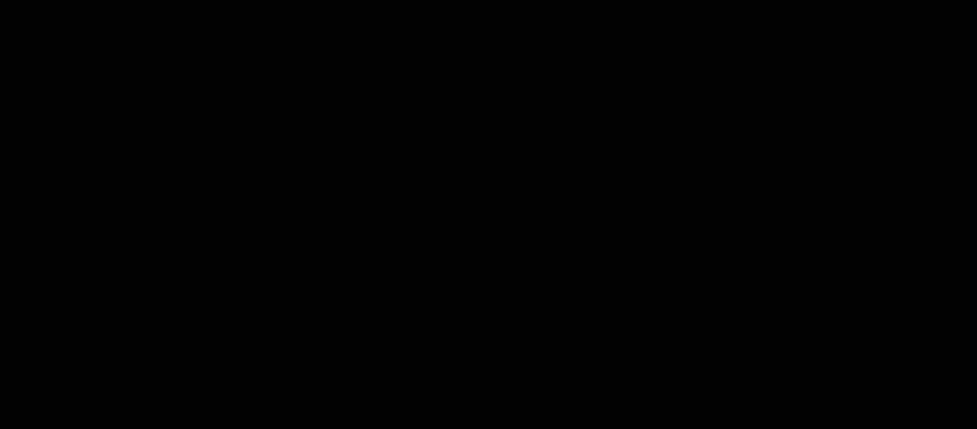
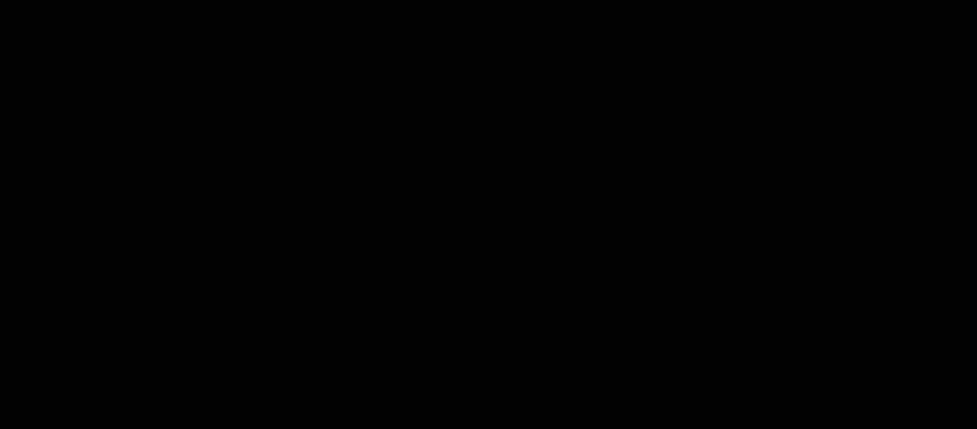
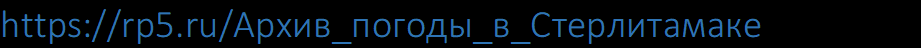
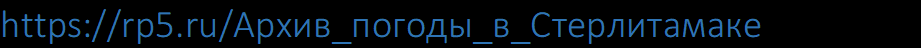

In [17]:
time   = []
values = []

with open('weather.csv', mode='r', encoding='utf-8') as file:
    dict_reader = csv.DictReader(file)
    for row in dict_reader:
        r = row["# Метеостанция Стерлитамак"]

        if "14:00" in r:
            time.append(r[0:10])

            end = r.index(";", 18)
            values.append(float(r[18:end - 1]))

time.reverse()
values.reverse()

# Лабораторная работа 1 - Определение типа процесса

## Задание 1 - Анализ графика исходного ряда

Исходный ряд


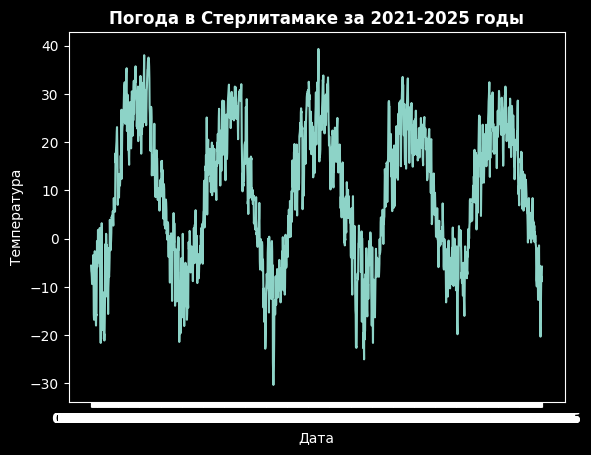

In [18]:
def original_schedule():
    print("Исходный ряд")
    plt.plot(time, values)
    plt.title("Погода в Стерлитамаке за 2021-2025 годы", fontweight='bold')
    plt.xlabel("Дата")
    plt.ylabel("Температура")
    plt.show()

original_schedule()

По графику можно сделать предварительный вывод, что процесс является стохастическим, причем ряд сразу является стационарным – «DS I (0)», так как ряд колеблется относительно горизонтальной линии и нет тренда вверх или вниз.
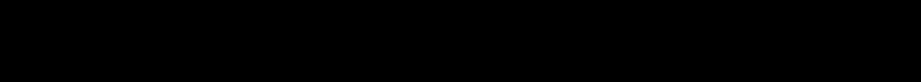
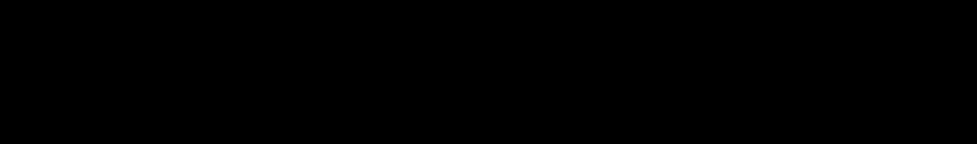

## Задание 2 - Анализ коррелограмм

АКФ и ЧАКФ исходного ряда


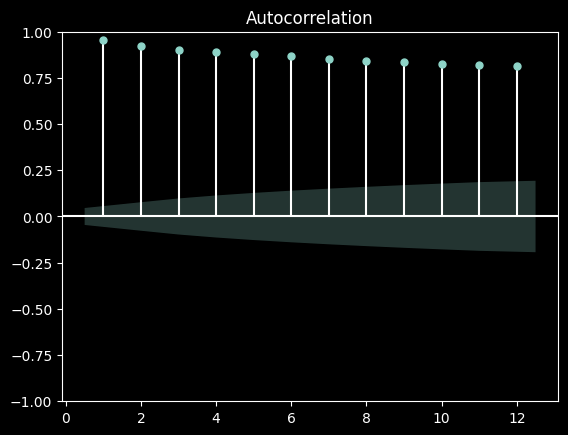

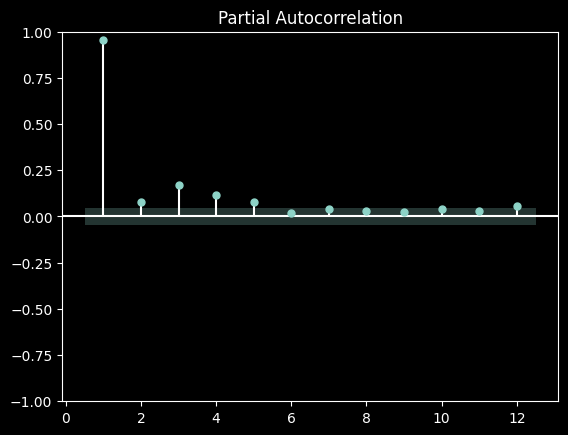

АКФ и ЧАКФ первых разностей


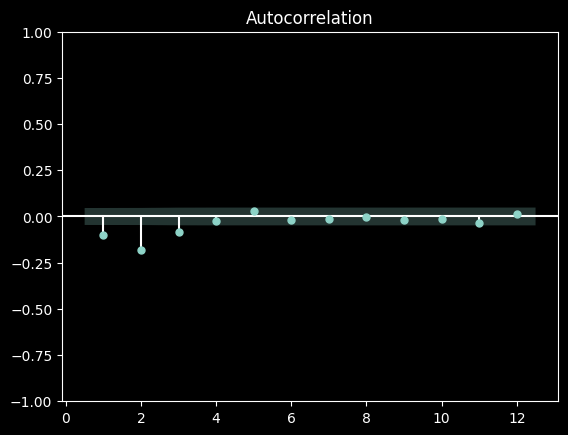

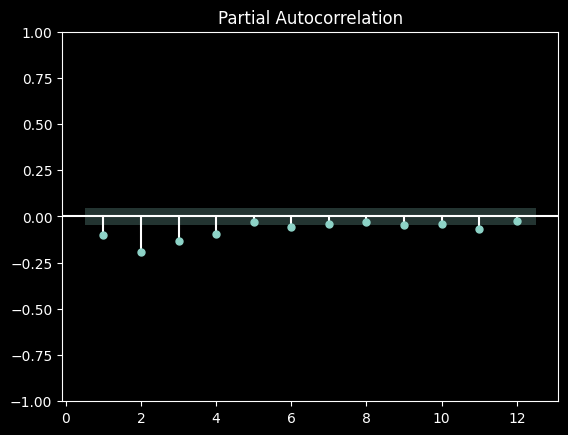

АКФ и ЧАКФ вторых разностей


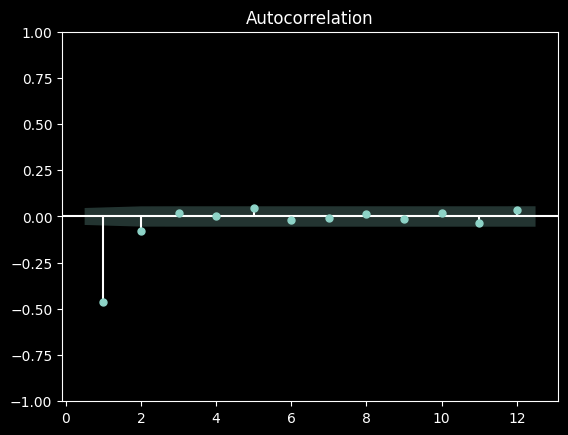

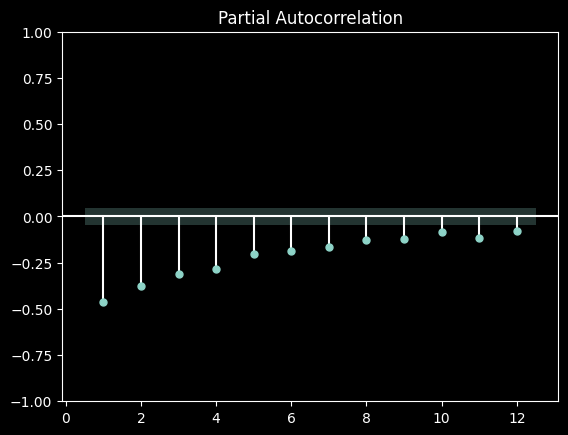

In [19]:
def acf_pacf(values, lags=None):

    if lags is None:
        lags = len(values) // 2

    plot_acf(values,  lags=lags, zero=False)
    plt.show()

    plot_pacf(values, lags=lags, zero=False)
    plt.show()



values_first_difference  = np.diff(values)
values_second_difference = np.diff(values, 2)
values_third_difference  = np.diff(values, 3)



print("АКФ и ЧАКФ исходного ряда")
acf_pacf(values,                   12)
print("АКФ и ЧАКФ первых разностей")
acf_pacf(values_first_difference,  12)
print("АКФ и ЧАКФ вторых разностей")
acf_pacf(values_second_difference, 12)

Коррелограмма исходного ряда имеет медленно убывающую по модулю АКФ, и при этом ЧАКФ имеет первый значимый лаг почти единицу, поэтому процесс может быть нестационарным и, возможно, содержит детерминированный тренд – «TS»; но так как на первых разностях коррелограммы резко убывающие и имеют значимыми только первые несколько лагов ЧАКФ, то процесс также может являться не только «TS», но и «DS I (1)».

## Задание 3 - Проведение тестов Дики-Фуллера

In [20]:
test_1          = adfuller(values_first_difference,  regression="ct", regresults=True)
test_2          = adfuller(values,                   regression="ct", regresults=True)
test_3          = adfuller(values_second_difference, regression="n",  regresults=True)
extended_test_3 = adfuller(values_second_difference, regression="c",  regresults=True)
test_4          = adfuller(values_first_difference,  regression="n",  regresults=True)
extended_test_4 = adfuller(values_first_difference,  regression="c",  regresults=True)
test_5          = adfuller(values,                   regression="n",  regresults=True)
extended_test_5 = adfuller(values,                   regression="c",  regresults=True)

tests       = [test_1, test_2, test_3, extended_test_3, test_4, extended_test_4, test_5, extended_test_5]
regressions = ["ct", "ct", "n", "c", "n", "c", "n", "c"]
test_names  = ["Тест 1              ", "Тест 2              ",
               "Тест 3              ", "Тест 3 (расширенный)",
               "Тест 4              ", "Тест 4 (расширенный)",
               "Тест 5              ", "Тест 5 (расширенный)"]

## Задание 4 - Определение типа процесса

In [21]:
result = []

for test, regression in zip(tests, regressions):
    # ADF-статистика
    if test[0] > test[2]["1%"]:
        result.append(False)
        continue

    # F-statistic
    if test[3].resols.f_pvalue >= 0.05:
        result.append(False)
        continue

    # p-value
    if regression == "ct":
        if max(test[3].resols.pvalues[0], test[3].resols.pvalues[-2], test[3].resols.pvalues[-1]) >= 0.05:
            result.append(False)
            continue
    elif regression == "c":
        if max(test[3].resols.pvalues[0], test[3].resols.pvalues[-1]) >= 0.05:
            result.append(False)
            continue
    else:
        if test[3].resols.pvalues[0] >= 0.05:
            result.append(False)
            continue

    # Durbin-Watson statistic
    if not(1.6 < durbin_watson(test[3].resols.resid) < 2.4):
        result.append(False)
        continue

    result.append(True)



print("Результаты тестов:")
for i in range(len(result)):
    if result[i]:
        print("- ", test_names[i], "- выполнен")
    else:
        print("- ", test_names[i], "- не выполнен")



if result[2] and result[4] and (result[6] or result[7]):
    res = "DS I(0)"
elif result[2] and (result[4] or result[5]):
    res = "DS I(1)"
elif result[2] or result[3]:
    res = "DS I(2)"
elif result[0] and result[1] and result[4]:
    res = "TS + DS"
elif result[0] and result[1]:
    res = "TS"
else:
    raise NameError("ТИП ПРОЦЕССА НЕ ОПРЕДЕЛЕН")

print("\nТип процесса: " + res)

Результаты тестов:
-  Тест 1               - не выполнен
-  Тест 2               - не выполнен
-  Тест 3               - выполнен
-  Тест 3 (расширенный) - не выполнен
-  Тест 4               - выполнен
-  Тест 4 (расширенный) - не выполнен
-  Тест 5               - не выполнен
-  Тест 5 (расширенный) - не выполнен

Тип процесса: DS I(1)


# Лабораторная работа 2 - Структурные изменения

## Задание 1 - Проведение теста Кванда-Эндрюса

In [22]:
t = np.arange(1, len(values) + 1)
X = sm.add_constant(t)

start = int(len(values) * 0.15)
end   = int(len(values) * 0.85)
k     = X.shape[1]

f_statistics = []
for i in range(start, end):
    x1, y1 = X[:i], values[:i]
    x2, y2 = X[i:], values[i:]

    S  = sm.OLS(values, X).fit().ssr
    S1 = sm.OLS(y1, x1).fit().ssr
    S2 = sm.OLS(y2, x2).fit().ssr

    f_statistics.append(((S - (S1 + S2)) / k) / ((S1 + S2) / (len(values) - 2 * k)))

breakpoint_index = start + f_statistics.index(max(f_statistics))
p_value = 1 - stats.f.cdf(max(f_statistics), k, len(values) - 2 * k)
print(f"Точка излома - {time[breakpoint_index]} (p-value: {p_value})")

Точка излома - 01.10.2021 (p-value: 0.0)


## Задание 2 - Ввод фиктивных переменных

In [23]:
ds  = [0] * breakpoint_index + [1] + [0] * (len(values) - breakpoint_index - 1)
ds1 = [0] * breakpoint_index + [1] * (len(values) - breakpoint_index)
dt  = [0] * breakpoint_index + [i for i in range(1, (len(values) - breakpoint_index) + 1)]

## Задание 3 - Построение моделей

In [24]:
def building_models(values, *variables: list):
    X     = sm.add_constant(np.column_stack(variables))
    model = sm.OLS(values, X).fit()
    return model



ds_first_difference   = ds[:-1]
ds_second_difference  = ds[:-2]
ds_third_difference   = ds[:-3]

ds1_first_difference  = ds1[:-1]
ds1_second_difference = ds1[:-2]
ds1_third_difference  = ds1[:-3]

values_for_first_difference = values[:-1]

values_first_difference_for_second_difference = values_first_difference[:-1]
values_second_difference_for_third_difference = values_second_difference[:-1]



if res == "TS + DS" or res == "TS":
    model_1 = building_models(values, t, dt)
    model_2 = building_models(values, t, ds1)
    model_3 = building_models(values, t, dt, ds1)

if res == "DS I(0)":
    model_1 = building_models(values_first_difference, values_for_first_difference, ds_first_difference)
    model_2 = building_models(values_first_difference, values_for_first_difference, ds1_first_difference)
    model_3 = building_models(values_first_difference, values_for_first_difference, ds_first_difference, ds1_first_difference)

if res == "DS I(1)":
    model_1 = building_models(values_second_difference, values_first_difference_for_second_difference, ds_second_difference)
    model_2 = building_models(values_second_difference, values_first_difference_for_second_difference, ds1_second_difference)
    model_3 = building_models(values_second_difference, values_first_difference_for_second_difference, ds_second_difference, ds1_second_difference)

if res == "DS I(2)":
    model_1 = building_models(values_third_difference, values_second_difference_for_third_difference, ds_third_difference)
    model_2 = building_models(values_third_difference, values_second_difference_for_third_difference, ds1_third_difference)
    model_3 = building_models(values_third_difference, values_second_difference_for_third_difference, ds_third_difference, ds1_third_difference)

## Задание 4 - Проверка статистической значимости

In [25]:
def significance_test(model):
    # F-statistic
    if model.f_pvalue >= 0.05:
        return False

    # p-value
    for i in model.pvalues[1:]:
        if i >= 0.05:
            return False

    # Durbin-Watson statistic
    if not(1.6 < durbin_watson(model.resid) < 2.4):
        return False

    return True

## Задание 5 - Оценка качества

In [26]:
model_1 = significance_test(model_1)
model_2 = significance_test(model_2)
model_3 = significance_test(model_3)

## Задание 6 - Определение типа процесса с учетом структурных изменений

In [27]:
if model_1 or model_2 or model_3:
    print(res + " со структурным скачком")
else:
    print(res + " без структурного скачка")

DS I(1) без структурного скачка


# Лабораторная работа 3 - Выделение детерминированных компонент из структуры ряда

## Задание 1 - Анализ графика исходного ряда

Исходный ряд


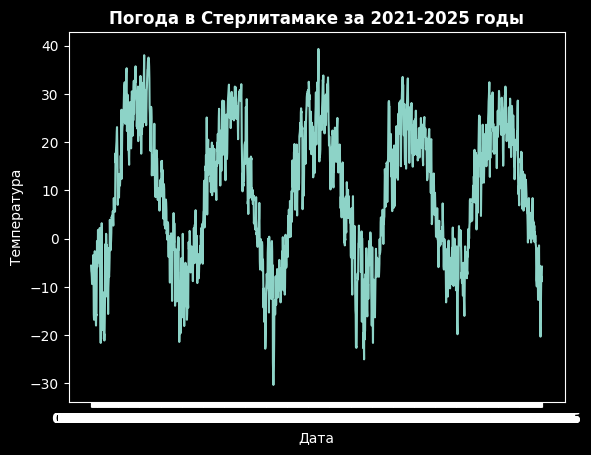

In [28]:
original_schedule()

По графику можно сделать следующие предварительные выводы:
- тренд отсутствует, так как ряд колеблется относительно горизонтальной линии;
- сезонность присутствует, так как видны регулярные достижения точек максимума и минимума с примерно одинаковым интервалом;
- присутствует аддитивное вхождение сезонной компоненты, так как амплитуда примерно одинаковая на протяжении всего ряда.
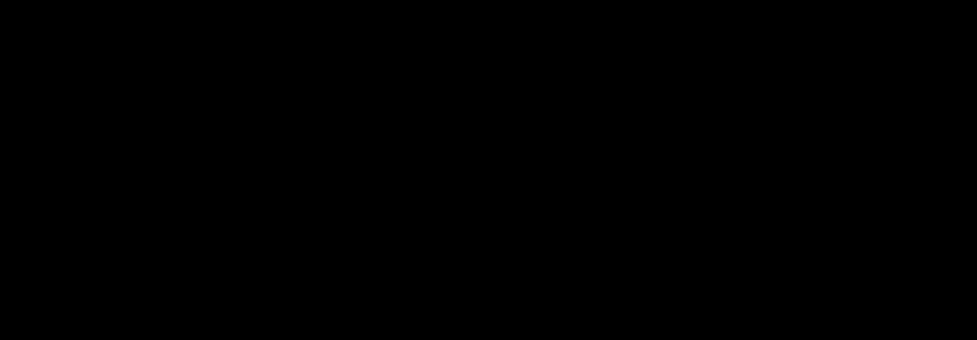

## Задание 4 - Удаление детерминированного тренда
## Задание 5 - Определение вида детерминированных компонент

In [29]:
def trend_removal():
    print("\n\n\n--- Задание 4 / Удаление детерминированного тренда ---")

    degrees = [t, np.pow(t, 2), np.pow(t, 3)]

    function  = ["Линейный", "Квадратичный", "Полиномиальный", "Логарифмический"]
    residuals = [sm.OLS(values, X).fit().resid,
                 sm.OLS(values, sm.add_constant(np.column_stack(degrees[:2]))).fit().resid,
                 sm.OLS(values, sm.add_constant(np.column_stack(degrees))).fit().resid,
                 sm.OLS(np.log(np.add(values, 1 - min(values))), X).fit().resid]



    print("\n\n\n--- Задание 5 / Определение вида детерминированных компонент ---")

    result = []

    for i in residuals:
        test = adfuller(i, regression="c", regresults=True)

        if test[0] > test[2]["1%"]:
            result.append(False)
        else:
            result.append(True)



    std = [np.std(i) for i in residuals]
    minimum = None

    print("Результаты тестов:")
    for i in range(len(result)):
        if result[i]:
            if minimum is None or minimum > std[i]:
                minimum = std[i]

            print(f"- {function[i]:<15} - выполнен    (стандартное отклонение - {std[i]})")
        else:
            print(f"- {function[i]:<15} - не выполнен (стандартное отклонение - {std[i]})")

    if minimum is not None:
        print(f"\n{function[std.index(minimum)]} вид детерминированных компонент")
    else:
        raise NameError("ТЕСТЫ НЕ ВЫПОЛНЕНЫ")



    if res == "TS":
        current_values = residuals[std.index(minimum)]
    else:
        current_values = np.diff(residuals[std.index(minimum)])

    trend_residuals = values - current_values

    return trend_residuals

## Задание 2 - Анализ коррелограмм

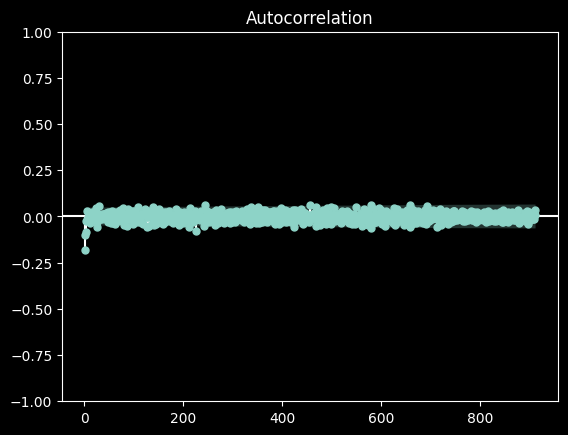

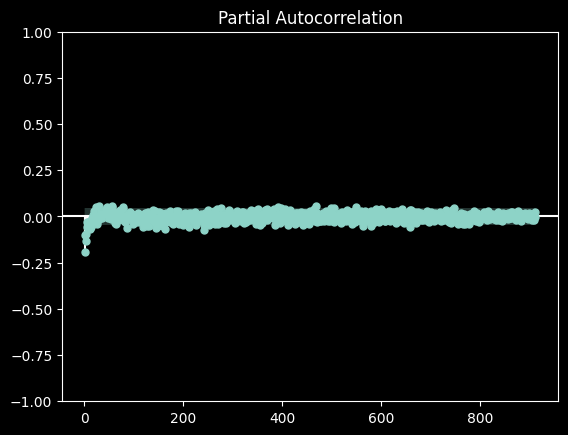

In [30]:
trend_residuals = None

if res == "DS I(0)":
    current_values = values.copy()

if res == "DS I(1)":
    current_values = values_first_difference.copy()

if res == "DS I(2)":
    current_values = values_second_difference.copy()

if res == "TS + DS" or res == "TS":
    current_values = trend_removal()

acf_pacf(current_values)

Согласно коррелограммам, можно сделать вывод об возможном наличии сезонности, так как, например, для 220 и 585 лагов коэффициенты являются статистически значимыми, то есть период сезонности примерно равен 365.
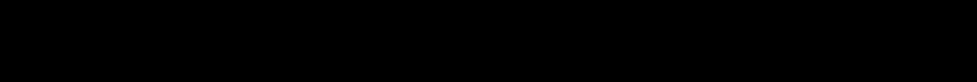

## Задание 3 - Выделение сезонности

In [31]:
def plot(values, residuals):
    plt.plot(time[:len(values)], values,                         "k", label="Исходный", linewidth=0.5)
    plt.plot(time[:len(values)], residuals,                      "b", label="Остатки",  linewidth=0.5)
    plt.plot(time[:len(values)], np.subtract(values, residuals), "r", label="Модель",   linewidth=1)
    plt.axhline(y=0, color="b", linestyle="-", linewidth=0.3)
    plt.legend()
    plt.show()

T = int(input("Введите период сезонности: "))

residuals = []
methods   = ["Первый способ   ", "Второй способ   ", "Третий способ   ", "Четвертый способ"]

### Первый способ: оценка сезонности с помощью тригонометрических функций


Первый способ:
- Индекс детерминации: 0.003290916500604979 (достигается при 10 * pi)


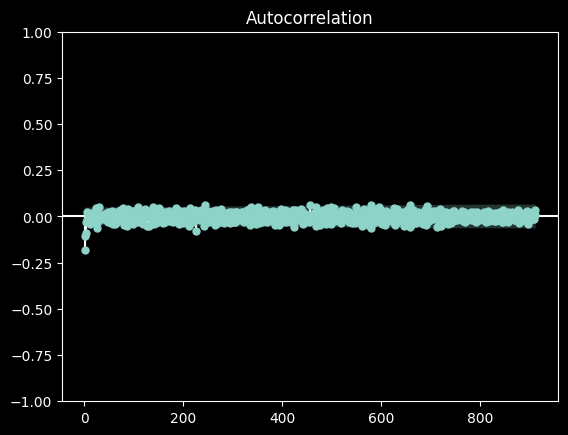

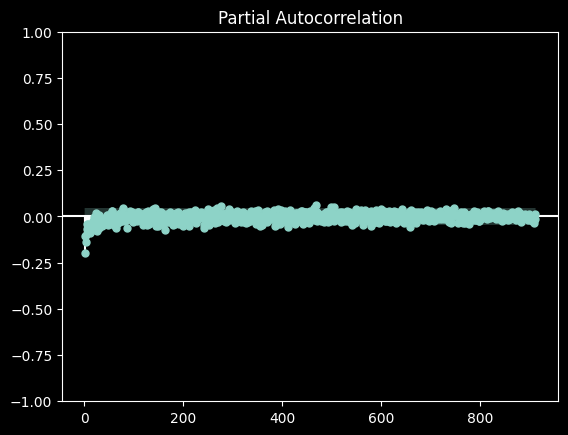

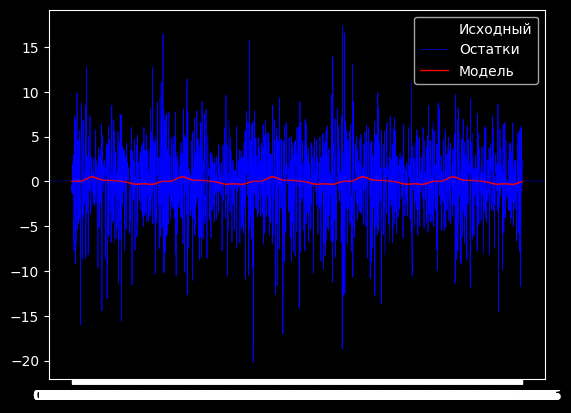

In [32]:
def first_method(values):
    best   = None
    best_n = 0

    harmonic = []

    for n in range(2, 11, 2):
        harmonic.append(np.sin(n * np.pi * t[:len(values)] / T))
        harmonic.append(np.cos(n * np.pi * t[:len(values)] / T))

        model = sm.OLS(values, sm.add_constant(np.column_stack(harmonic))).fit()

        if best is None or abs(1.0 - model.rsquared) < abs(1.0 - best.rsquared):
            best    = model
            best_n = n

    residuals.append(best.resid)

    print("\nПервый способ:")
    print(f"- Индекс детерминации: {best.rsquared} (достигается при {best_n} * pi)")
    acf_pacf(best.resid)
    plot(values, best.resid)



first_method(current_values)

### Второй способ: оценка методом сезонных поправок (индексов)


Второй способ:


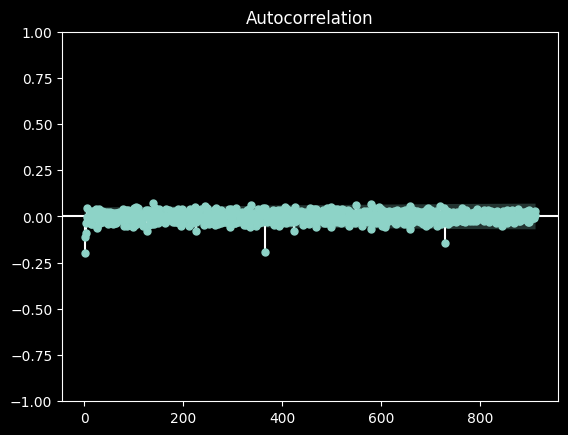

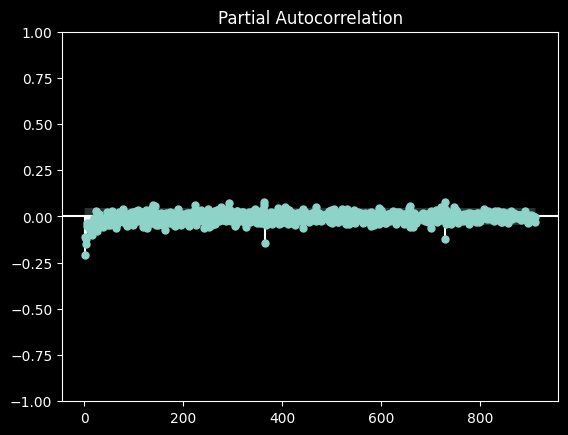

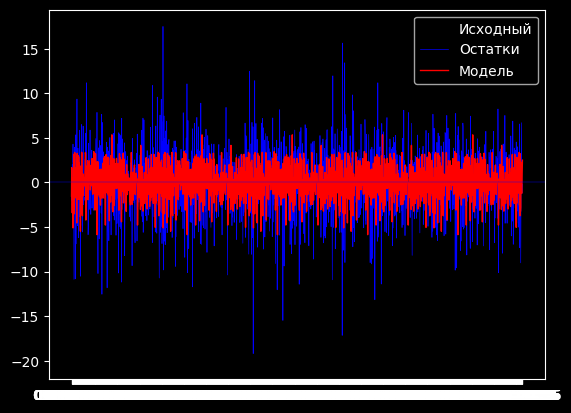

In [33]:
def second_method(values):
    S = []

    for i in range(len(values)):
        S.append(np.mean([values[j] for j in range(i % 365, len(values), T)]))

    residuals.append(np.subtract(values, S))

    print("\nВторой способ:")
    acf_pacf(residuals[-1])
    plot(values, residuals[-1])



second_method(current_values)

### Третий способ: оценка методом введения фиктивных переменных


Третий способ:
- Индекс детерминации: 0.2034230345993937


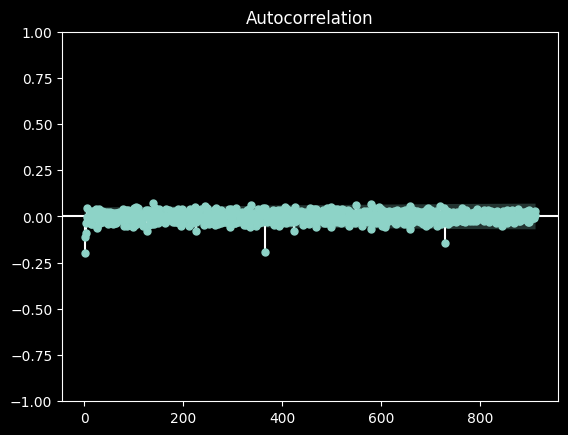

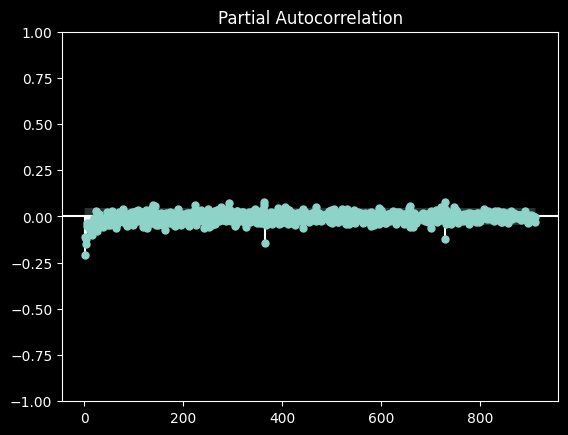

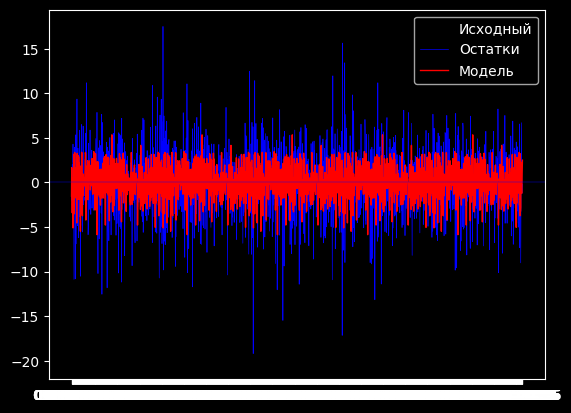

In [36]:
def third_method(values):
    D = []

    for i in range(T - 1):
        d = np.zeros(len(values))
        for j in range(i, len(values), T):
            d[j] = 1
        D.append(d)

    model = sm.OLS(values, sm.add_constant(np.column_stack(D))).fit()

    residuals.append(model.resid)

    print("\nТретий способ:")
    print("- Индекс детерминации:", model.rsquared)
    acf_pacf(model.resid)
    plot(values, model.resid)



third_method(current_values)

### Четвертый способ: метод сезонной декомпозиции временного ряда "Census X12"


Четвертый способ:


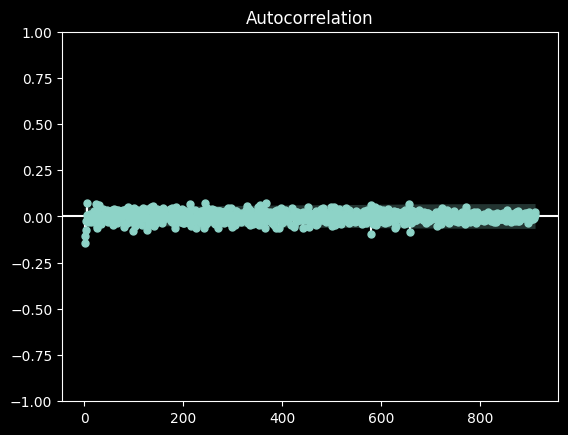

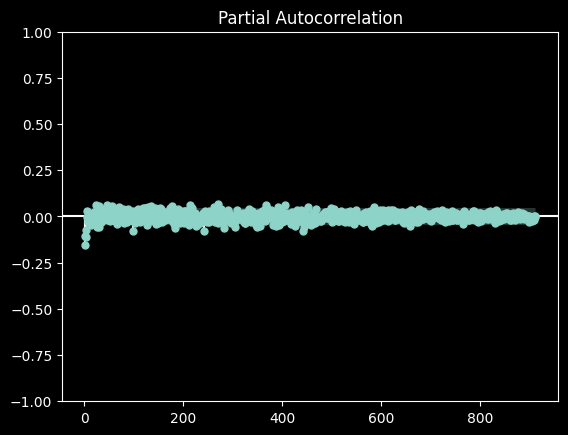

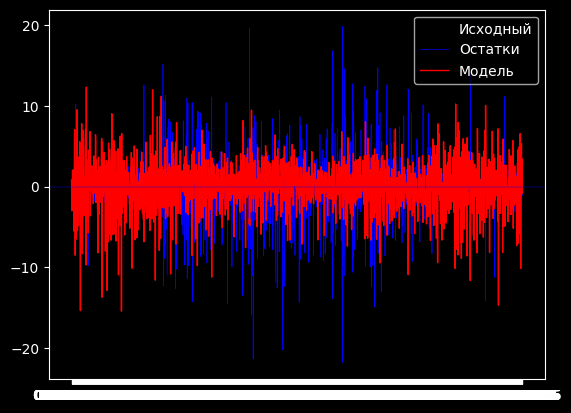

In [37]:
def fourth_method(values):
    model = STL(pd.Series(values), period=T, robust=True).fit()

    residuals.append(model.resid)

    print("\nЧетвертый способ:")
    acf_pacf(model.resid)
    plot(values, model.resid)



fourth_method(current_values)

### Сравнение и выбор лучшего метода оценки сезонной компоненты

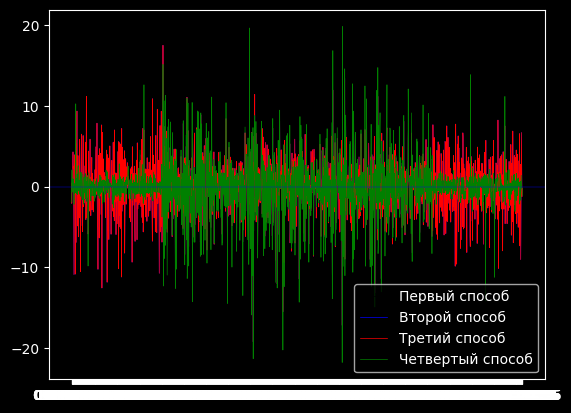

- Первый способ   : среднее значение -   -1.3334843123169004e-16 / стандартное отклонение - 4.118337141926196
- Второй способ   : среднее значение -   -1.4600193200550002e-17 / стандартное отклонение - 3.6817268134351204
- Третий способ   : среднее значение -    -6.380284428640351e-15 / стандартное отклонение - 3.6817268134351204
- Четвертый способ: среднее значение -      -0.09549208158279397 / стандартное отклонение - 3.4820843539063606

Лучший: Четвертый способ


In [38]:
if len(residuals) == 4:
    plt.plot(time[:len(residuals[0])], residuals[0], "k", label=methods[0], linewidth=0.5)
    plt.plot(time[:len(residuals[0])], residuals[1], "b", label=methods[1], linewidth=0.5)
    plt.plot(time[:len(residuals[0])], residuals[2], "r", label=methods[2], linewidth=0.5)
    plt.plot(time[:len(residuals[0])], residuals[3], "g", label=methods[3], linewidth=0.5)
    plt.axhline(y=0, color="b", linestyle="-", linewidth=0.3)
    plt.legend()
    plt.show()

    std = [np.std(i) for i in residuals]

    for i in range(len(residuals)):
        print(f"- {methods[i]}: среднее значение - {np.mean(residuals[i]):>25} / стандартное отклонение - {std[i]}")

    best_seasonality = std.index(min(std))
    print(f"\nЛучший: {methods[best_seasonality]}")

# Лабораторная работа 4 - Моделирование с помощью ARIMA-инструментов

## Задание 1 - Определение зависимой переменной

In [39]:
if res in ("DS I(0)", "DS I(1)", "DS I(2)"):
    exog = None

if res == "TS" or res == "TS + DS":
    exog = t



current_values = residuals[best_seasonality].copy()

## Задание 2 - Идентификация модели

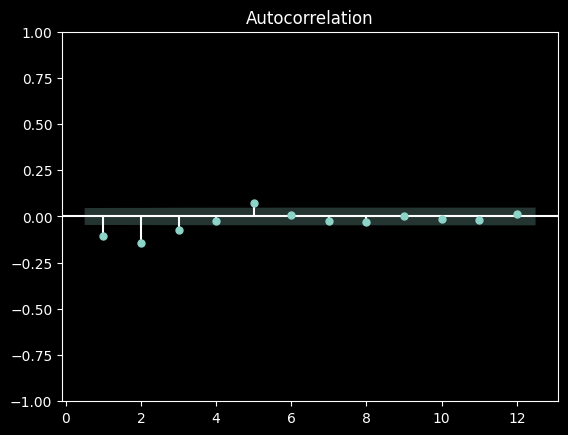

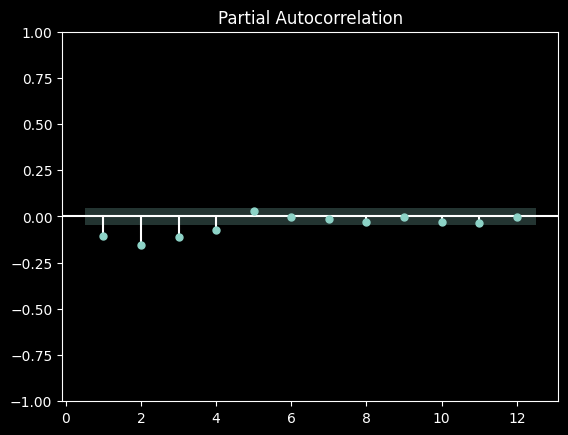

In [41]:
acf_pacf(current_values, 12)

- Порядок AR - это последний значимый лаг 'ЧАКФ' перед первым незначимым (4)
- Порядок MA - это последний значимый лаг 'АКФ' перед первым незначимым (3)

## Задание 3 - Построение модели

In [42]:
p = int(input("Введите последний значимый лаг 'ЧАКФ' перед первым незначимым: "))
q = int(input("Введите последний значимый лаг  'АКФ' перед первым незначимым: "))

## Задание 4 - Диагностика модели

Диагностика модели с 'p' = 4 и 'q' = 3:
- max(p-value(коэффициенты))           - не выполнено (0.8685485879788082)


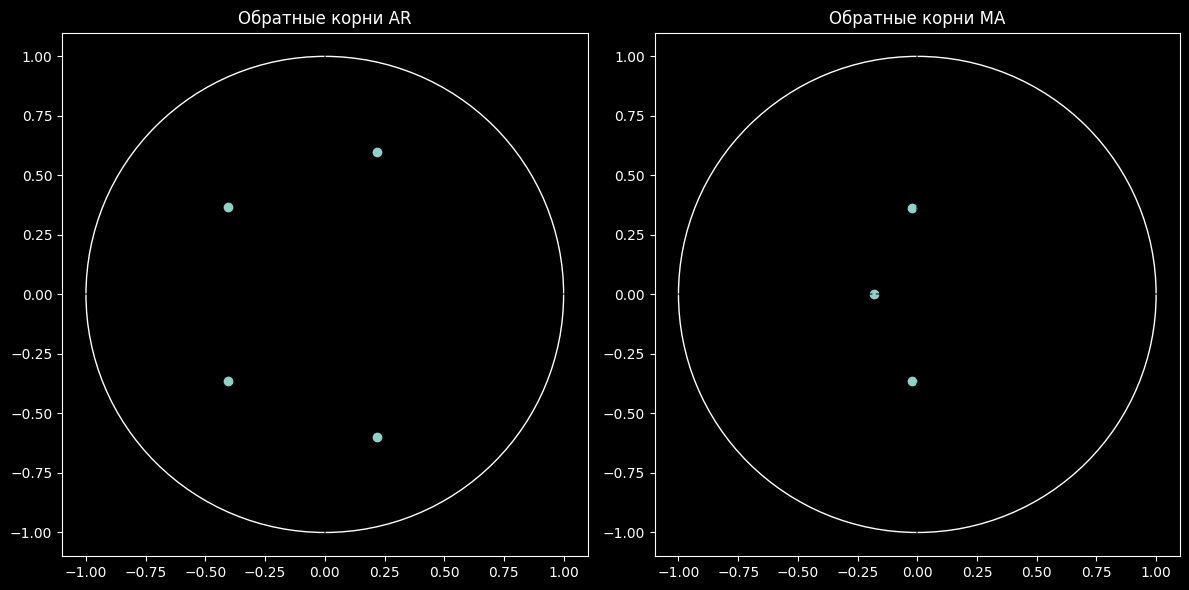

- Структура единичных корней           -    выполнено


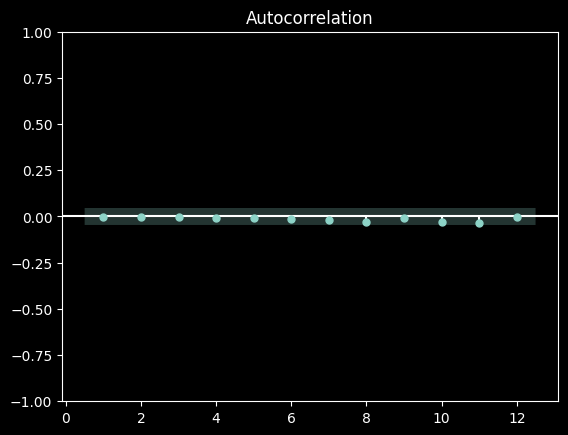

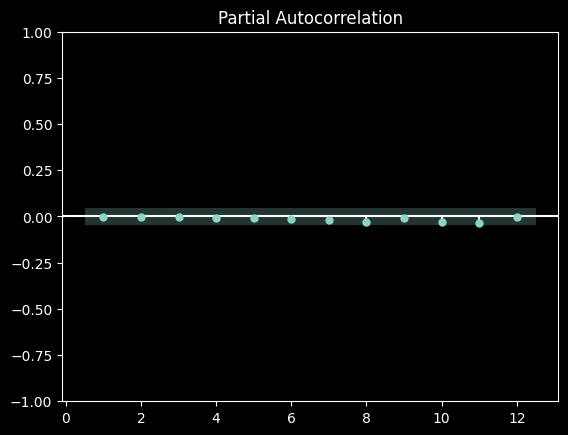

- Коррелограммы                        -    выполнено
- Durbin-Watson statistic              -    выполнено (2.0001220365672525)
- R-squared (коэффициент детерминации) - не выполнено (0.05260336534406074)
- p-value(F-statistic)                 -    выполнено (0.0)


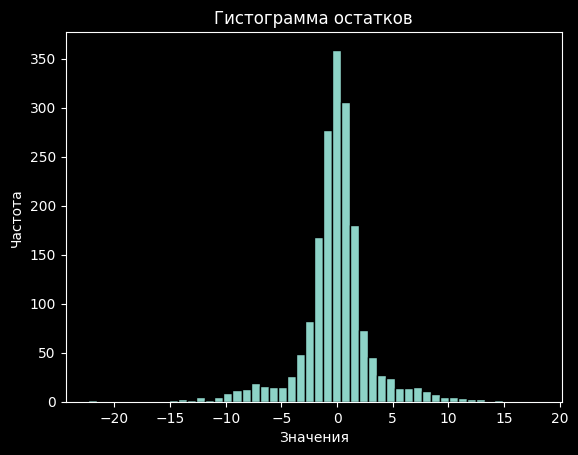

- p-value(тест Бера–Жарка)             - не выполнено (0.0)
Диагностика модели с 'p' = 4 и 'q' = 3 не пройдена (выполнено условий: 4)

Диагностика модели с 'p' = 4 и 'q' = 2:
- max(p-value(коэффициенты))           - не выполнено (0.419525956566268)


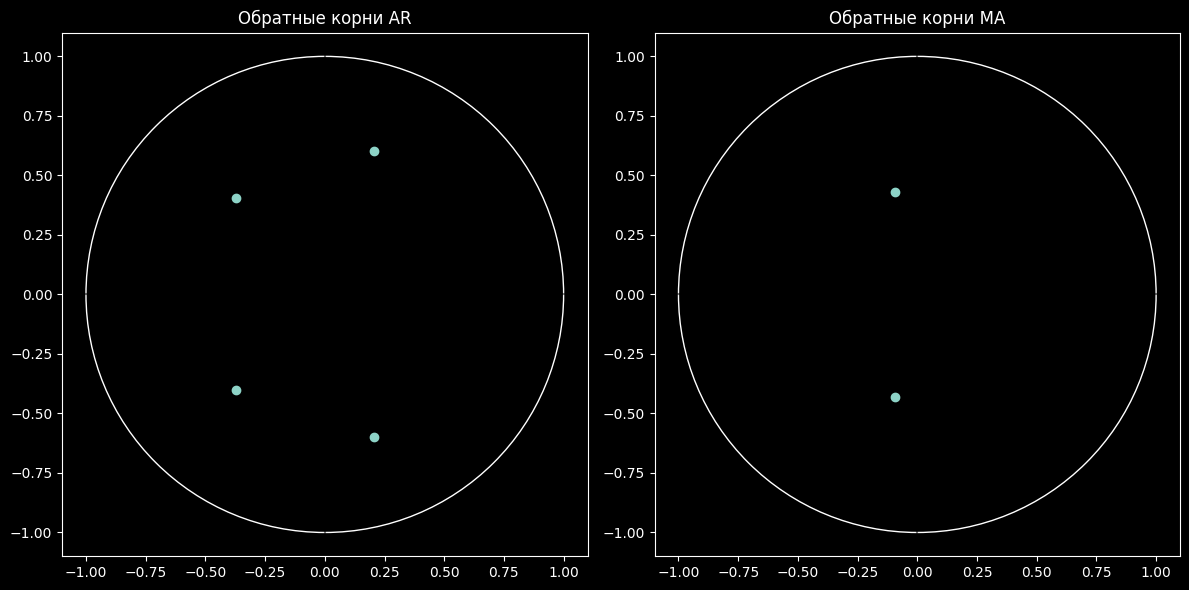

- Структура единичных корней           -    выполнено


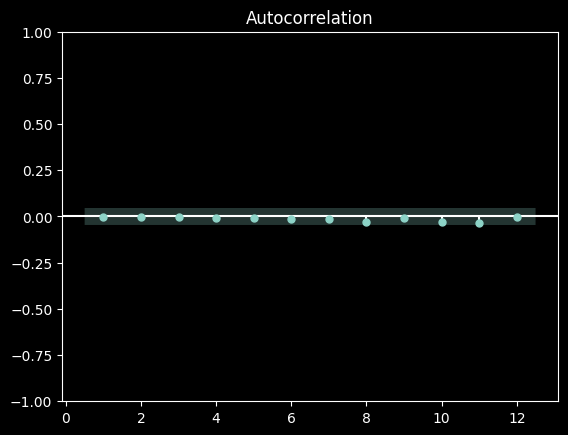

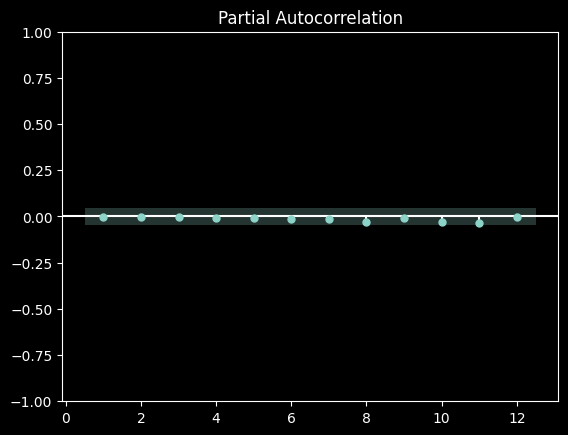

- Коррелограммы                        -    выполнено
- Durbin-Watson statistic              -    выполнено (2.0000020223193236)
- R-squared (коэффициент детерминации) - не выполнено (0.052607503532061006)
- p-value(F-statistic)                 -    выполнено (0.0)


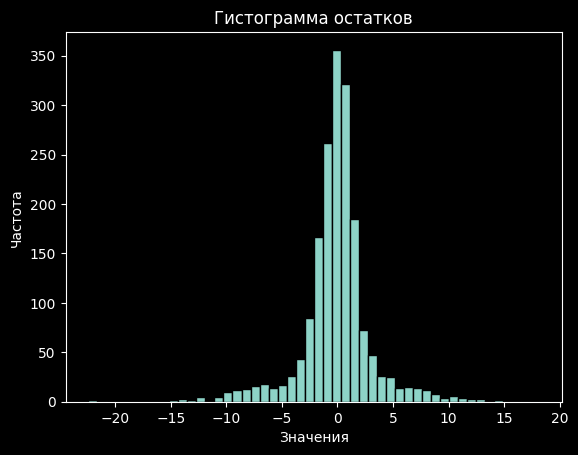

- p-value(тест Бера–Жарка)             - не выполнено (0.0)
Диагностика модели с 'p' = 4 и 'q' = 2 не пройдена (выполнено условий: 4)

Диагностика модели с 'p' = 4 и 'q' = 1:
- max(p-value(коэффициенты))           - не выполнено (0.08536596912703284)


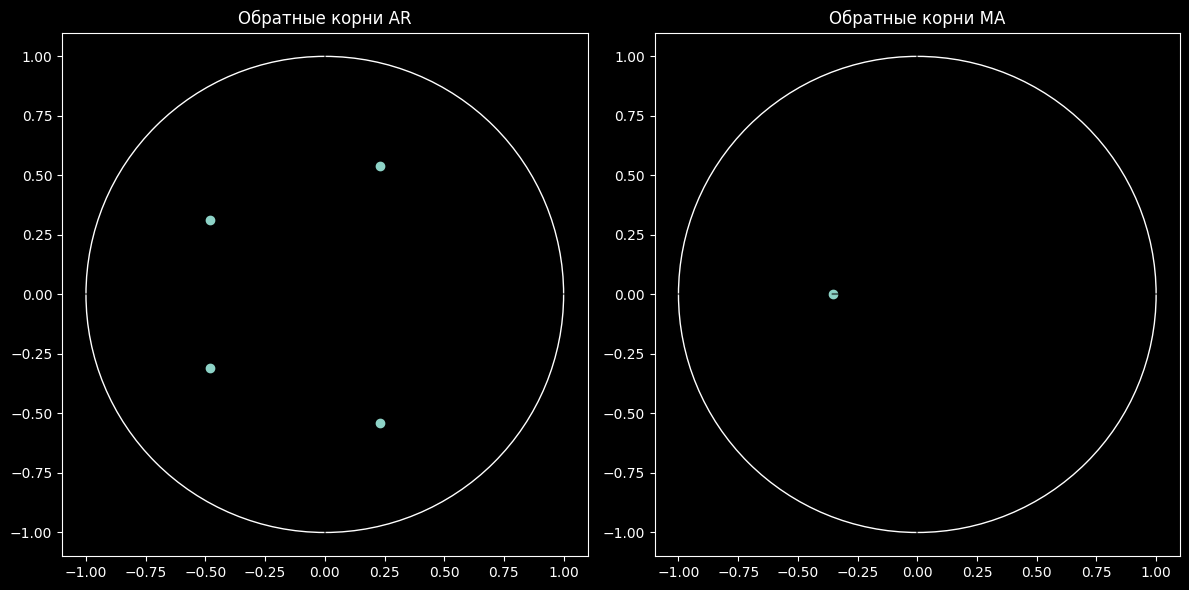

- Структура единичных корней           -    выполнено


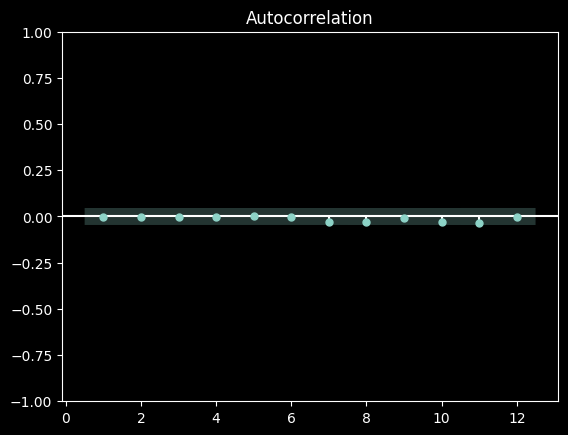

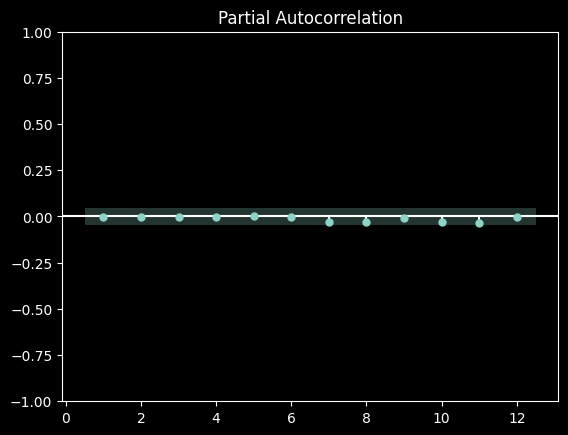

- Коррелограммы                        - не выполнено
- Durbin-Watson statistic              -    выполнено (1.9991225743334655)
- R-squared (коэффициент детерминации) - не выполнено (0.05239223215057476)
- p-value(F-statistic)                 -    выполнено (0.0)


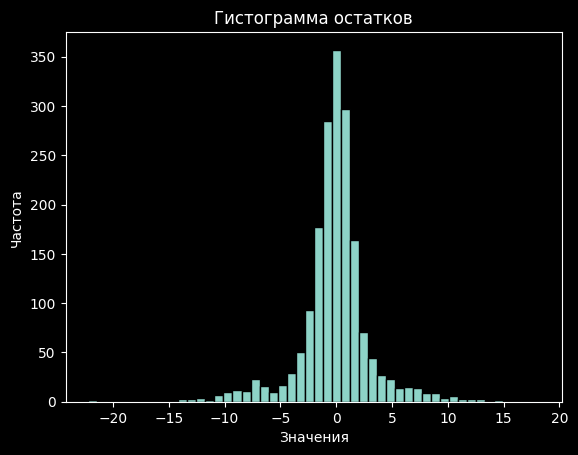

- p-value(тест Бера–Жарка)             - не выполнено (0.0)
Диагностика модели с 'p' = 4 и 'q' = 1 не пройдена (выполнено условий: 3)

Диагностика модели с 'p' = 3 и 'q' = 3:
- max(p-value(коэффициенты))           - не выполнено (0.9142449291165289)


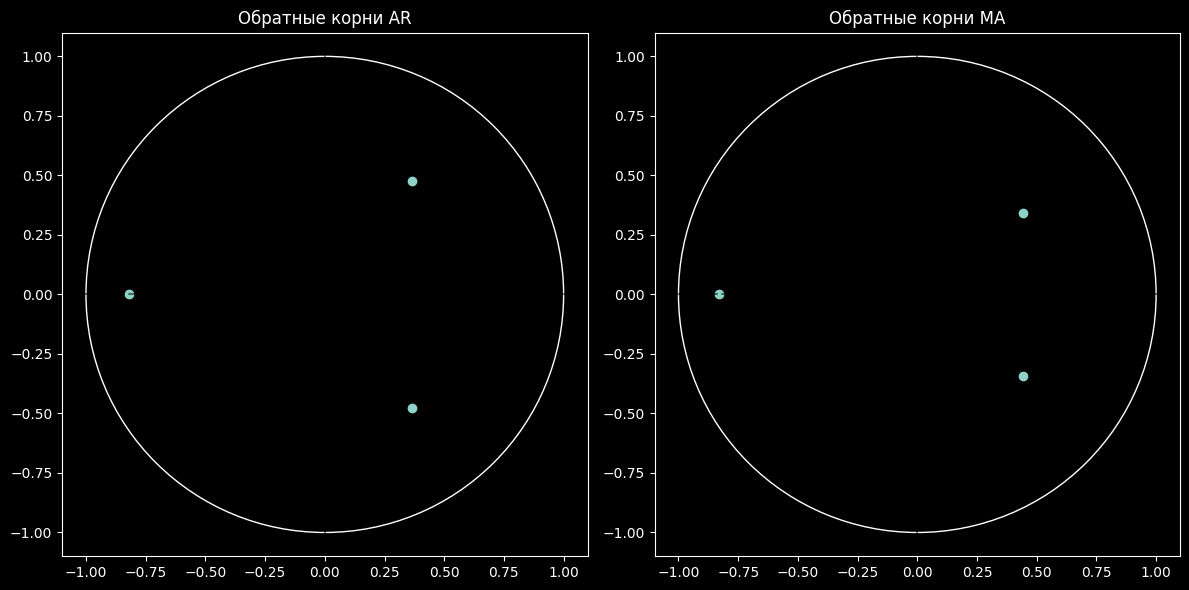

- Структура единичных корней           -    выполнено


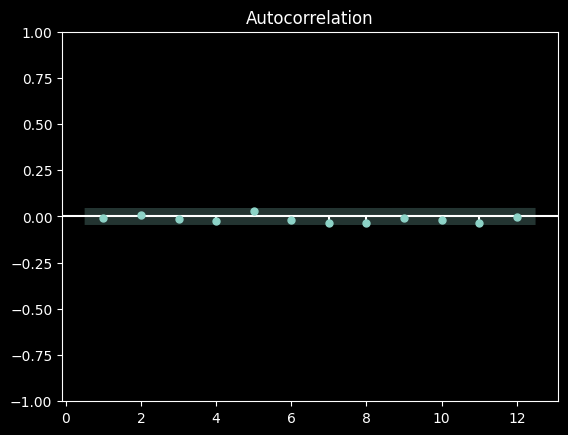

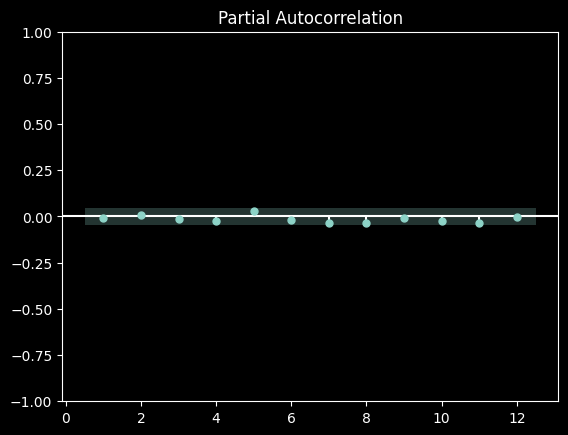

- Коррелограммы                        - не выполнено
- Durbin-Watson statistic              -    выполнено (2.00970943548739)
- R-squared (коэффициент детерминации) - не выполнено (0.04986603878543838)
- p-value(F-statistic)                 -    выполнено (0.0)


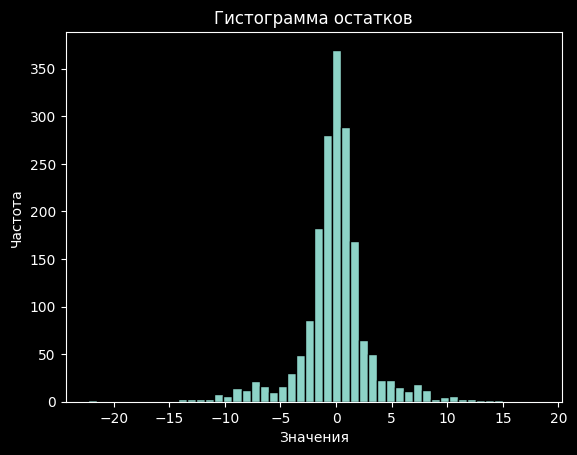

- p-value(тест Бера–Жарка)             - не выполнено (0.0)
Диагностика модели с 'p' = 3 и 'q' = 3 не пройдена (выполнено условий: 3)

Диагностика модели с 'p' = 3 и 'q' = 2:
- max(p-value(коэффициенты))           - не выполнено (0.23598311511352665)


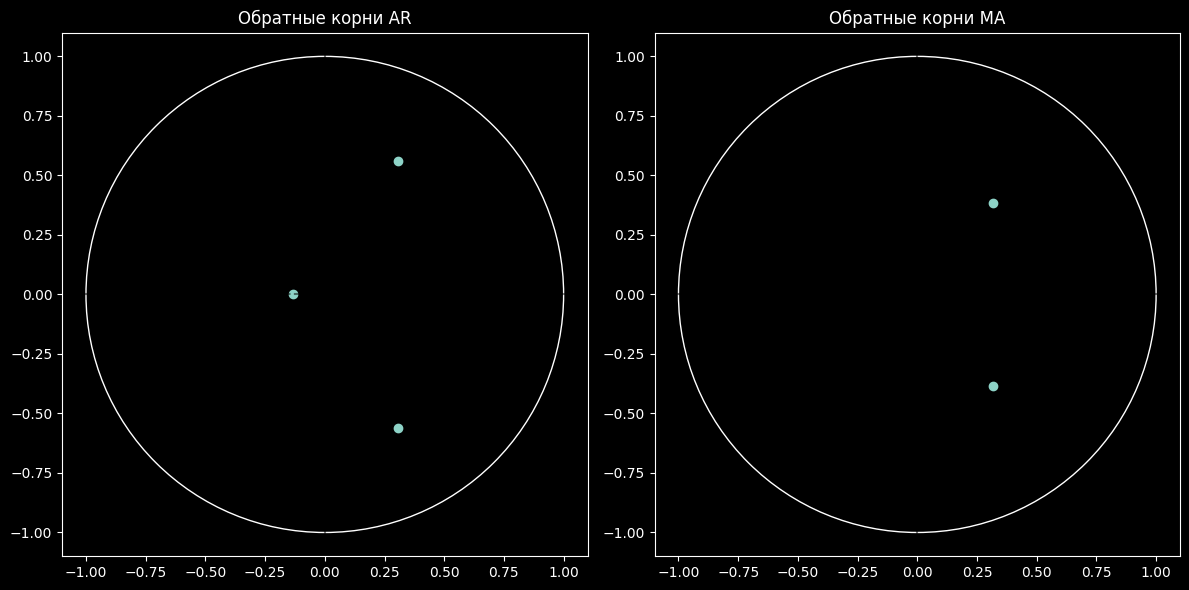

- Структура единичных корней           -    выполнено


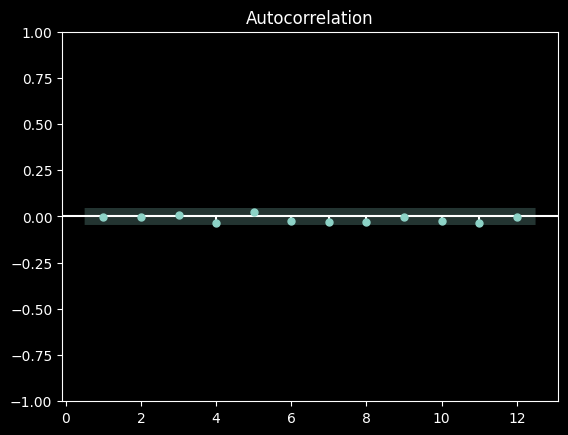

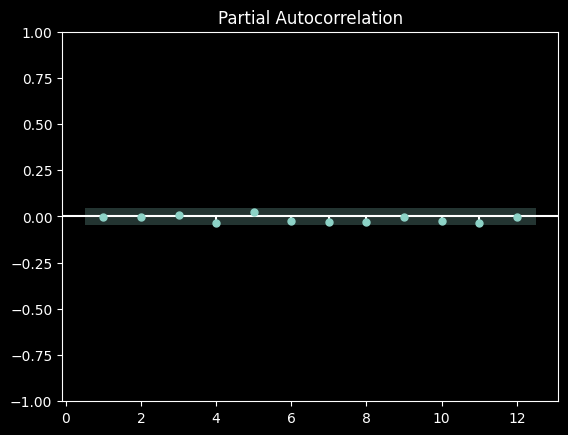

- Коррелограммы                        - не выполнено
- Durbin-Watson statistic              -    выполнено (2.0012398826061752)
- R-squared (коэффициент детерминации) - не выполнено (0.05019753933634907)
- p-value(F-statistic)                 -    выполнено (0.0)


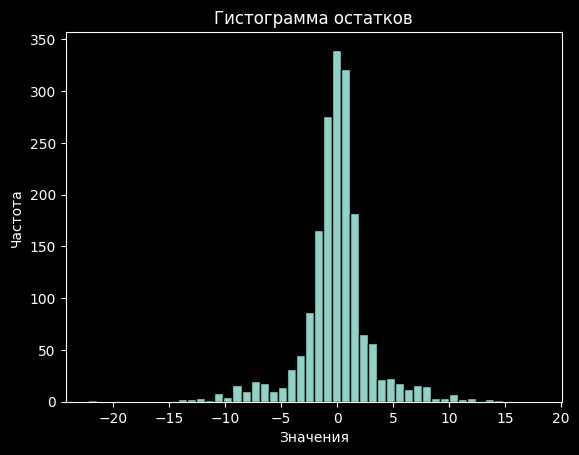

- p-value(тест Бера–Жарка)             - не выполнено (0.0)
Диагностика модели с 'p' = 3 и 'q' = 2 не пройдена (выполнено условий: 3)

Диагностика модели с 'p' = 3 и 'q' = 1:
- max(p-value(коэффициенты))           - не выполнено (0.11436163171843229)


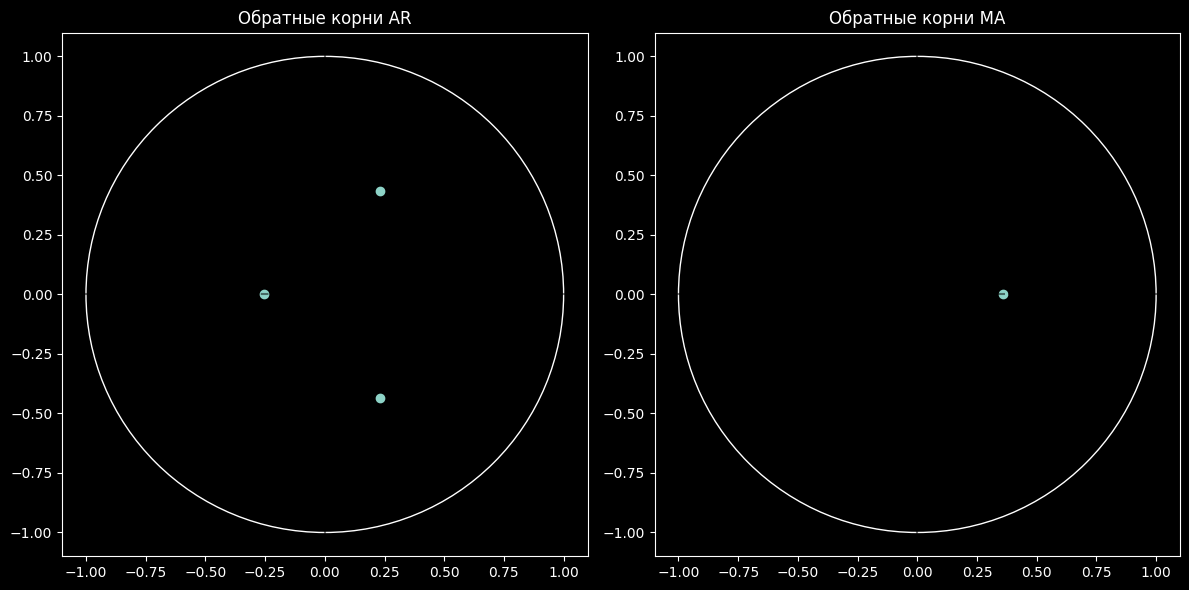

- Структура единичных корней           -    выполнено


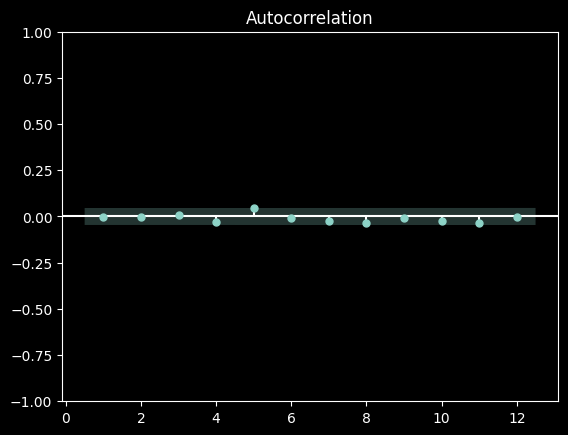

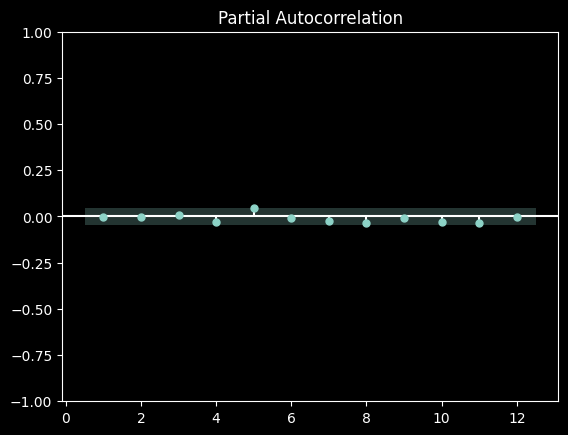

- Коррелограммы                        - не выполнено
- Durbin-Watson statistic              -    выполнено (2.001694241497372)
- R-squared (коэффициент детерминации) - не выполнено (0.049443093091391055)
- p-value(F-statistic)                 -    выполнено (0.0)


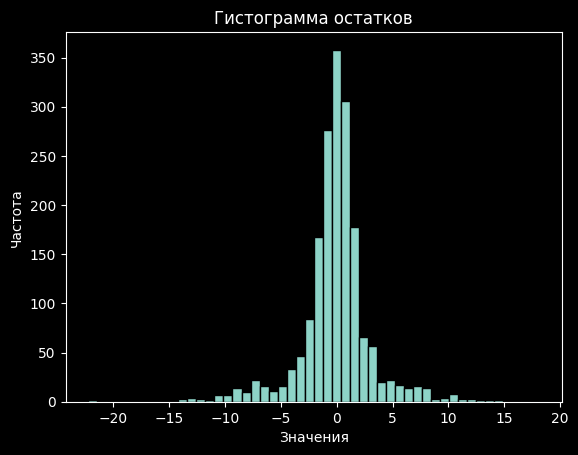

- p-value(тест Бера–Жарка)             - не выполнено (0.0)
Диагностика модели с 'p' = 3 и 'q' = 1 не пройдена (выполнено условий: 3)

Диагностика модели с 'p' = 2 и 'q' = 3:
- max(p-value(коэффициенты))           - не выполнено (0.06095226314925685)


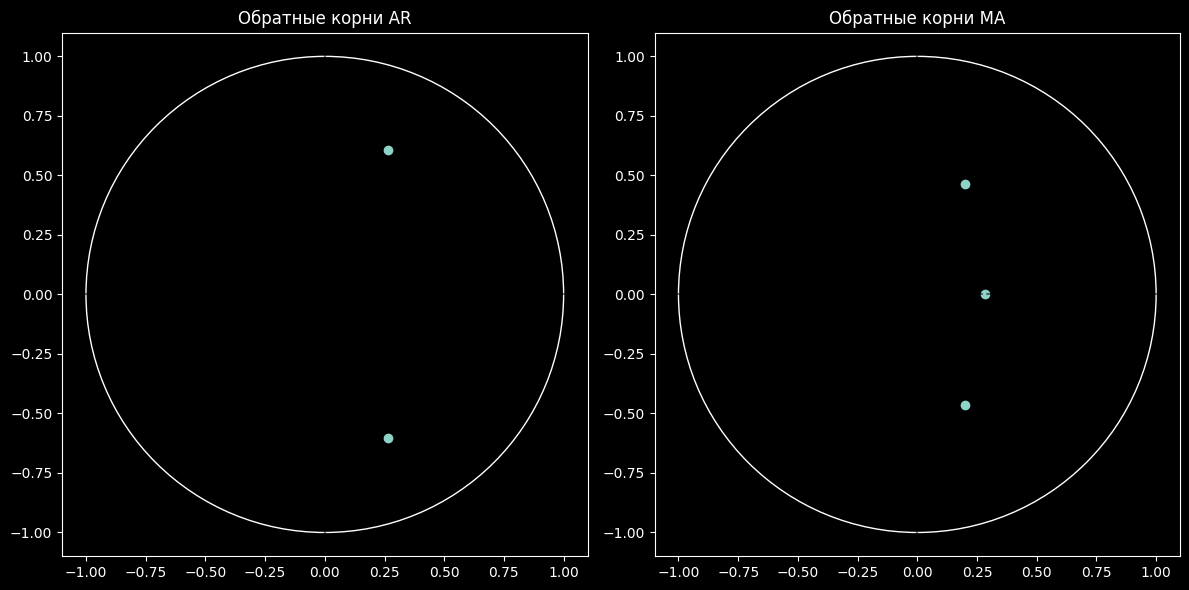

- Структура единичных корней           -    выполнено


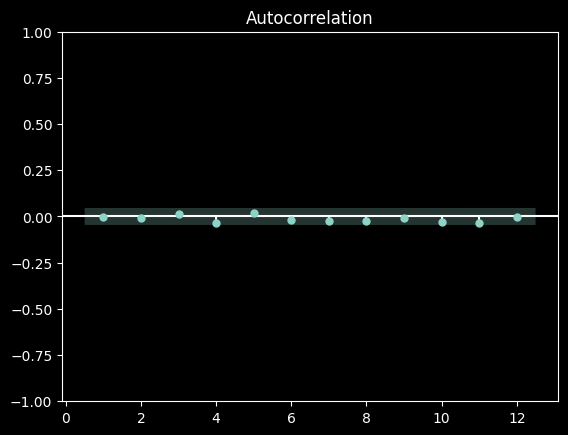

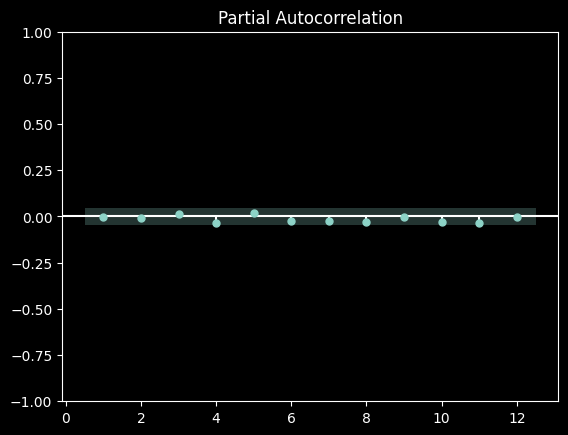

- Коррелограммы                        - не выполнено
- Durbin-Watson statistic              -    выполнено (1.9973538962476918)
- R-squared (коэффициент детерминации) - не выполнено (0.050541698522891254)
- p-value(F-statistic)                 -    выполнено (0.0)


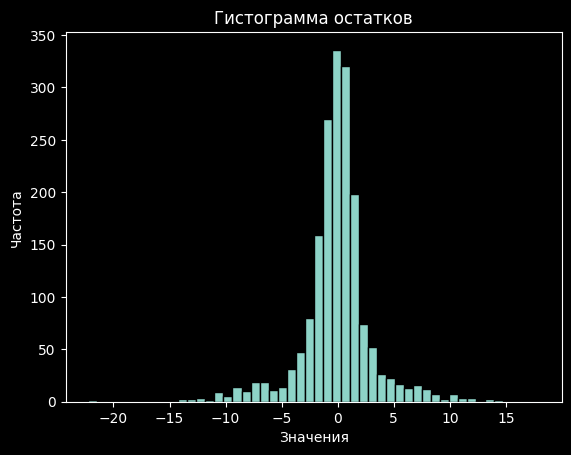

- p-value(тест Бера–Жарка)             - не выполнено (0.0)
Диагностика модели с 'p' = 2 и 'q' = 3 не пройдена (выполнено условий: 3)

Диагностика модели с 'p' = 2 и 'q' = 2:
- max(p-value(коэффициенты))           -    выполнено (0.009820316454235029)


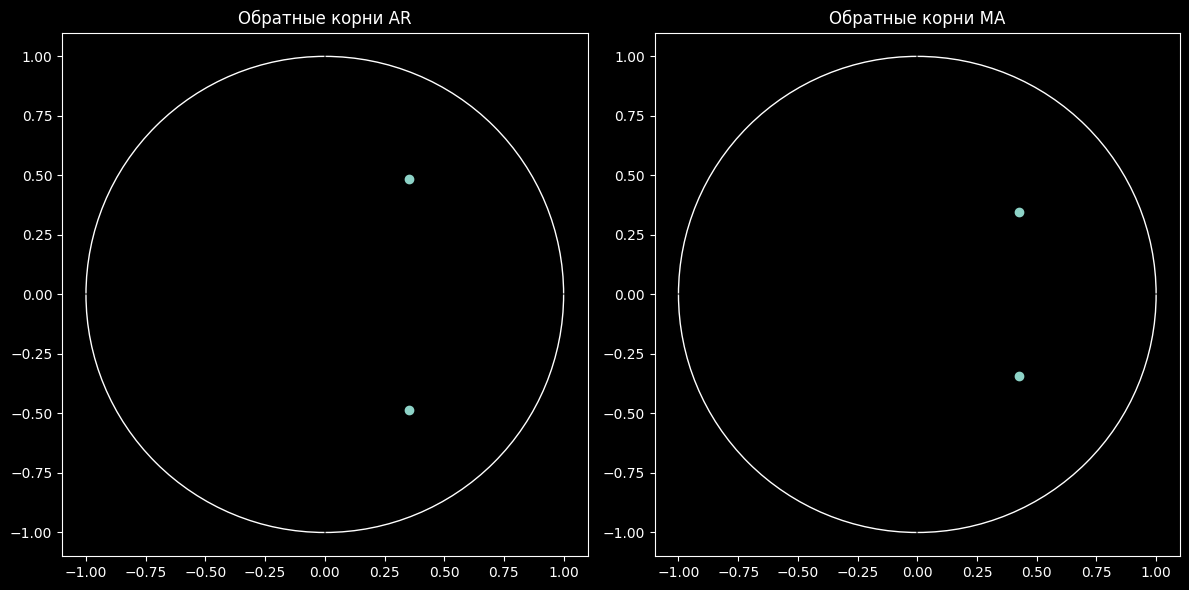

- Структура единичных корней           -    выполнено


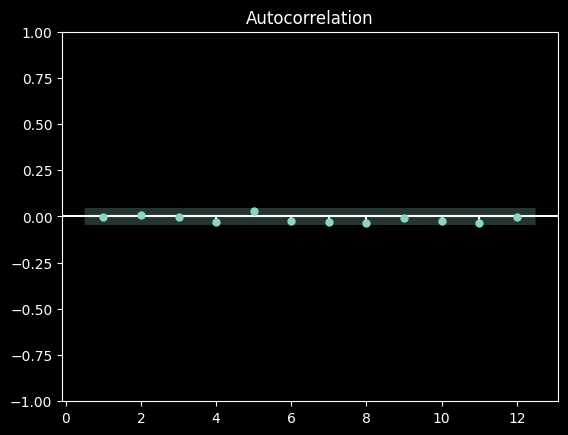

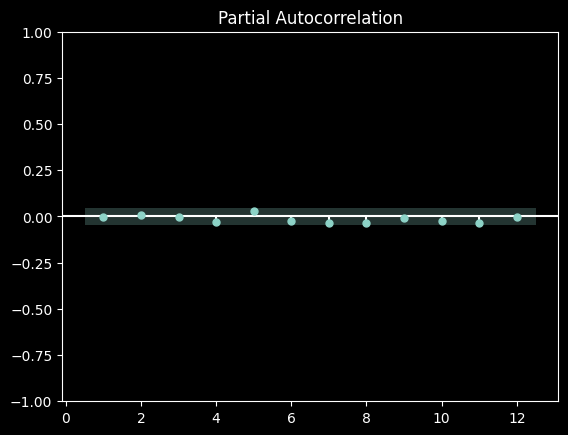

- Коррелограммы                        - не выполнено
- Durbin-Watson statistic              -    выполнено (2.0071590458818407)
- R-squared (коэффициент детерминации) - не выполнено (0.049611184111303386)
- p-value(F-statistic)                 -    выполнено (0.0)


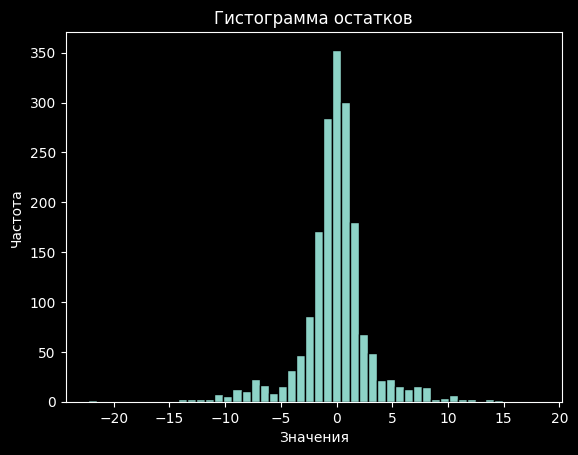

- p-value(тест Бера–Жарка)             - не выполнено (0.0)
Диагностика модели с 'p' = 2 и 'q' = 2 не пройдена (выполнено условий: 4)

Диагностика модели с 'p' = 2 и 'q' = 1:
- max(p-value(коэффициенты))           -    выполнено (5.008104122907641e-07)


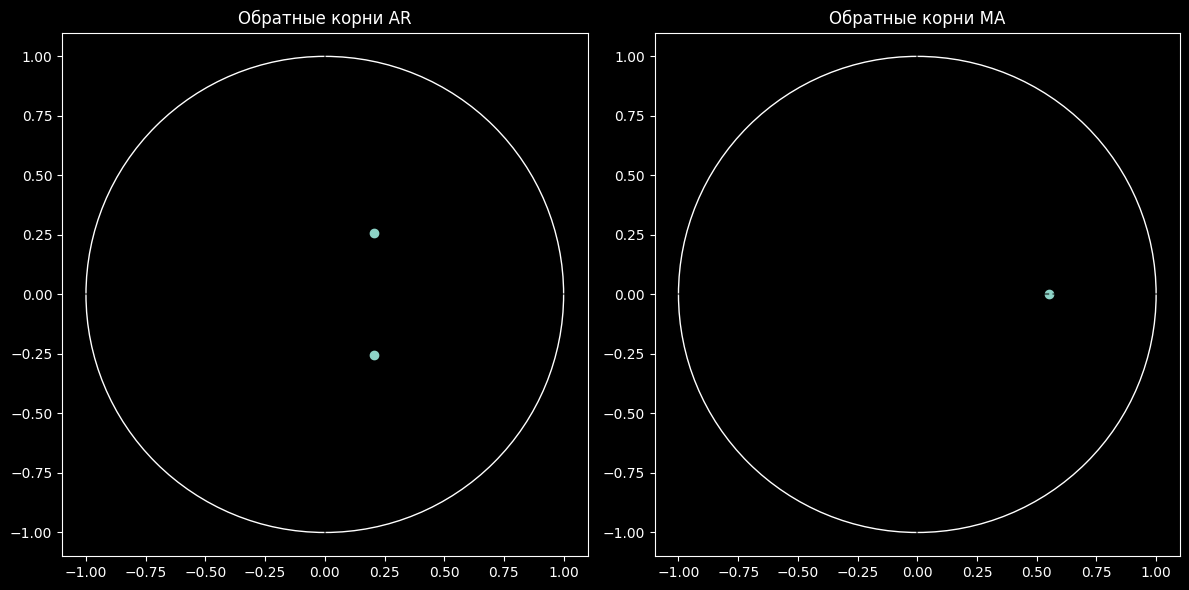

- Структура единичных корней           -    выполнено


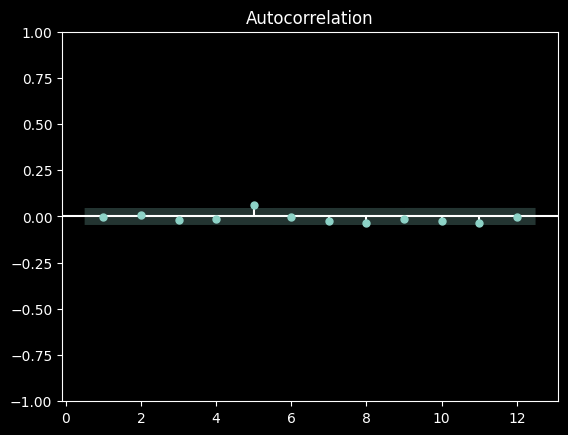

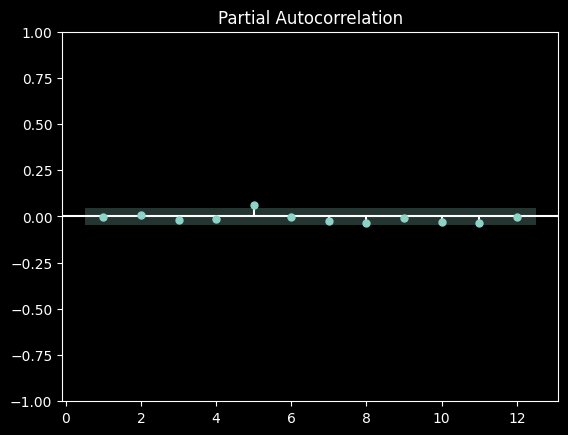

- Коррелограммы                        - не выполнено
- Durbin-Watson statistic              -    выполнено (2.0035181219367044)
- R-squared (коэффициент детерминации) - не выполнено (0.048305535106063835)
- p-value(F-statistic)                 -    выполнено (0.0)


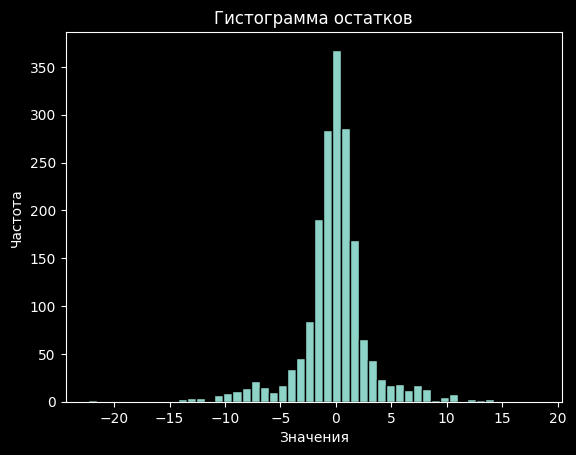

- p-value(тест Бера–Жарка)             - не выполнено (0.0)
Диагностика модели с 'p' = 2 и 'q' = 1 не пройдена (выполнено условий: 4)

Диагностика модели с 'p' = 1 и 'q' = 3:
- max(p-value(коэффициенты))           - не выполнено (0.7977247289633952)


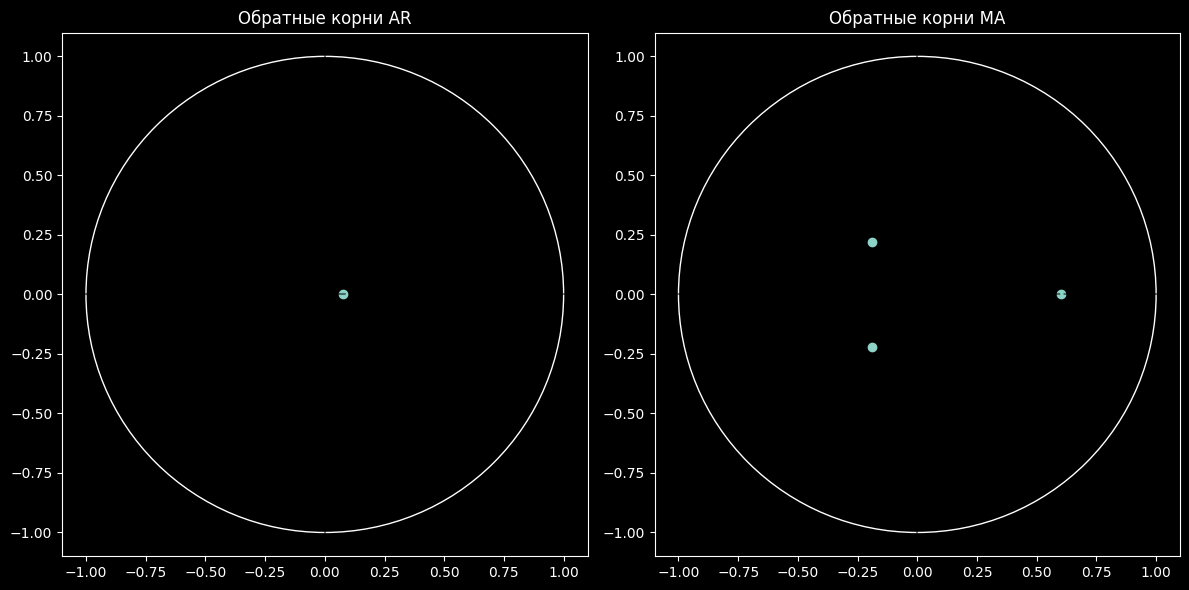

- Структура единичных корней           -    выполнено


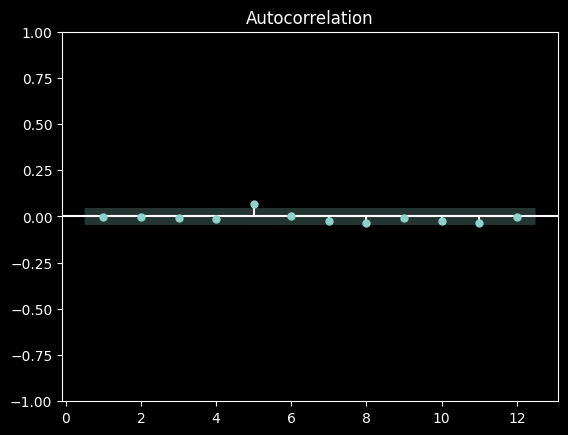

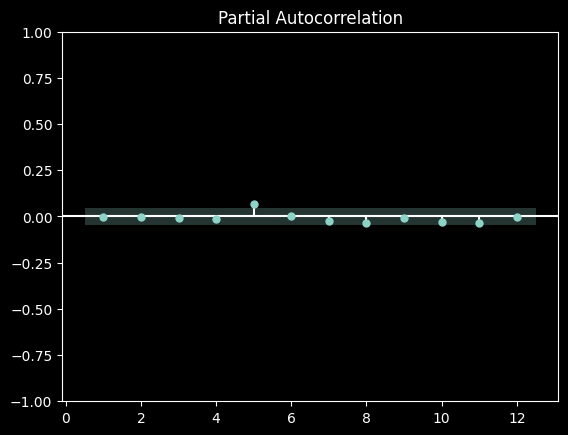

- Коррелограммы                        - не выполнено
- Durbin-Watson statistic              -    выполнено (1.9995138750792236)
- R-squared (коэффициент детерминации) - не выполнено (0.04808778242237255)
- p-value(F-statistic)                 -    выполнено (0.0)


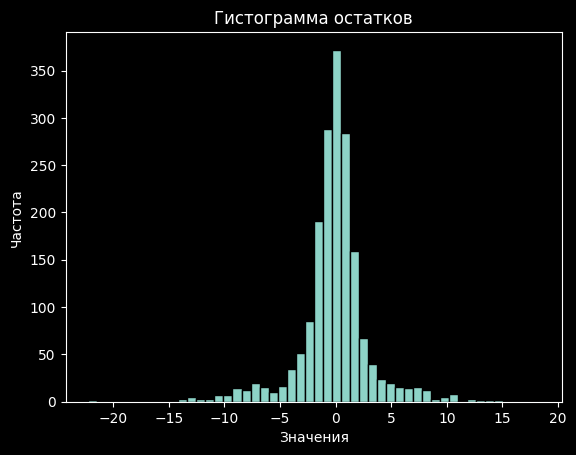

- p-value(тест Бера–Жарка)             - не выполнено (0.0)
Диагностика модели с 'p' = 1 и 'q' = 3 не пройдена (выполнено условий: 3)

Диагностика модели с 'p' = 1 и 'q' = 2:
- max(p-value(коэффициенты))           -    выполнено (0.0017214929522190263)


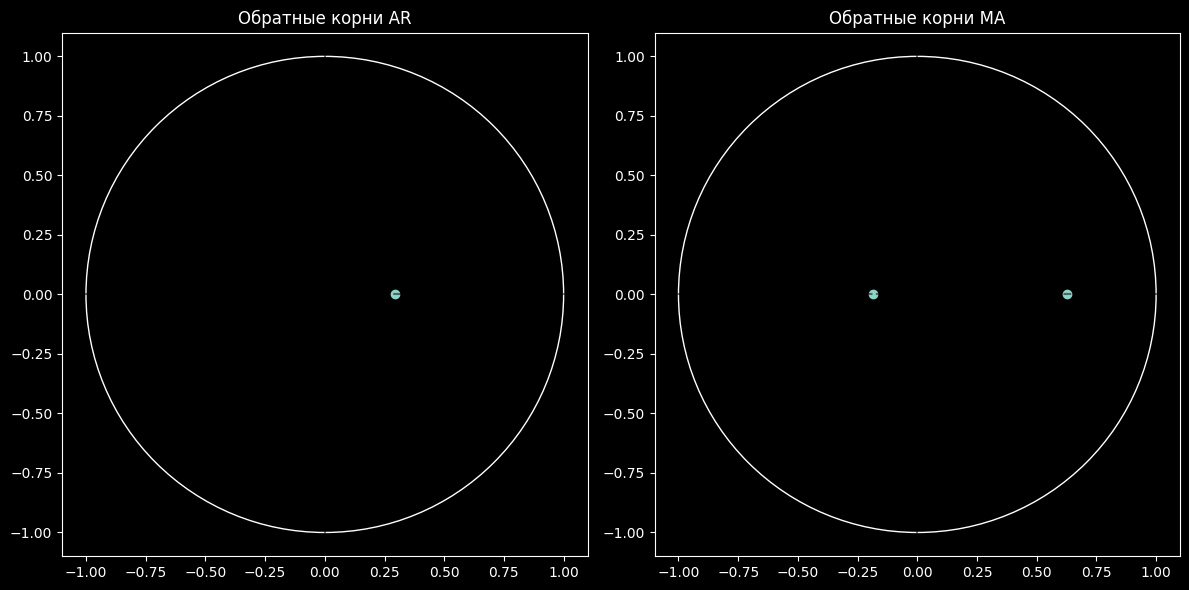

- Структура единичных корней           -    выполнено


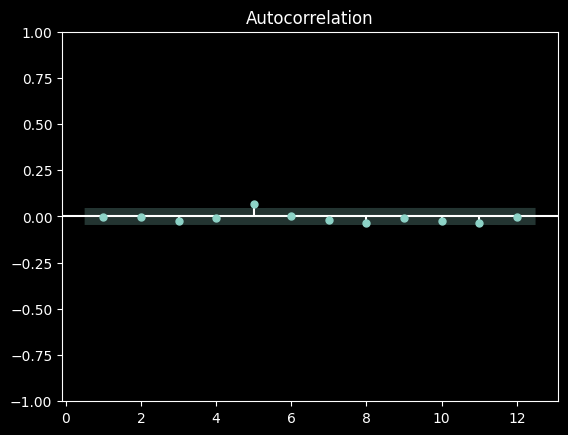

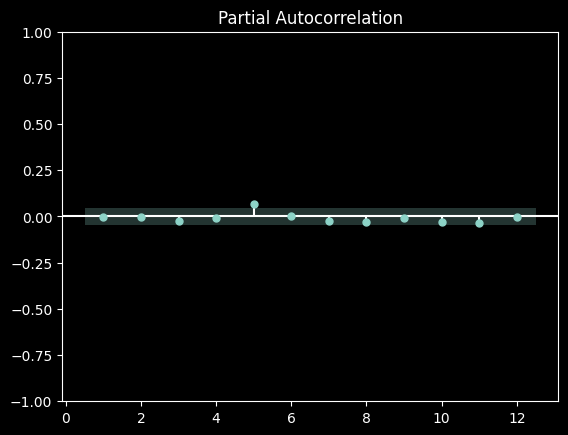

- Коррелограммы                        - не выполнено
- Durbin-Watson statistic              -    выполнено (1.997987934081718)
- R-squared (коэффициент детерминации) - не выполнено (0.047590706136793504)
- p-value(F-statistic)                 -    выполнено (0.0)


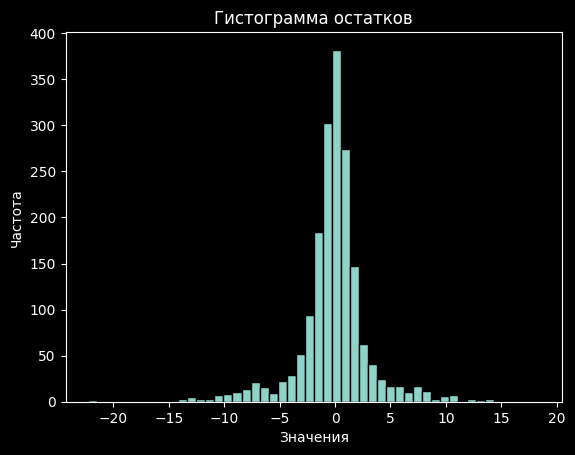

- p-value(тест Бера–Жарка)             - не выполнено (0.0)
Диагностика модели с 'p' = 1 и 'q' = 2 не пройдена (выполнено условий: 4)

Диагностика модели с 'p' = 1 и 'q' = 1:
- max(p-value(коэффициенты))           -    выполнено (7.012017441761543e-36)


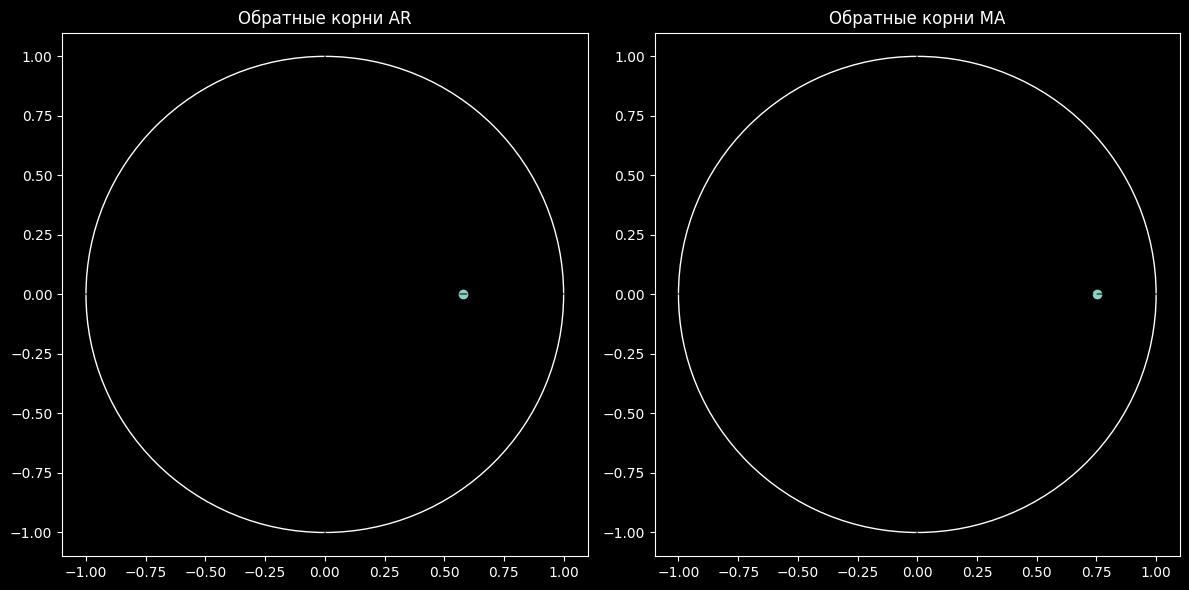

- Структура единичных корней           -    выполнено


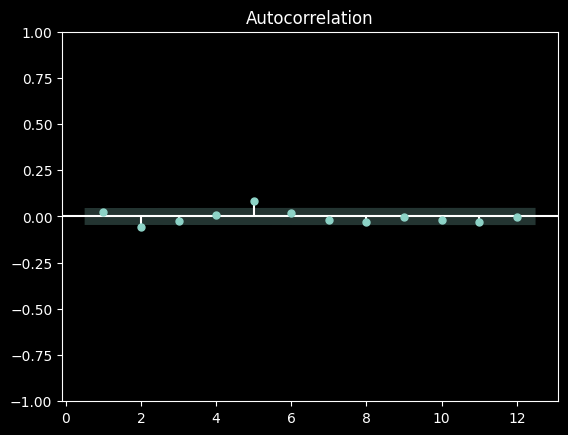

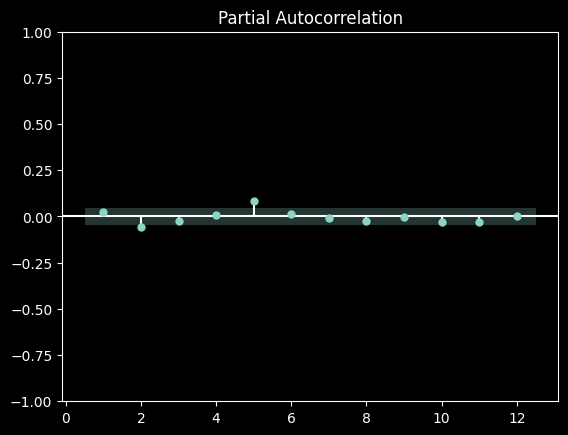

- Коррелограммы                        - не выполнено
- Durbin-Watson statistic              -    выполнено (1.9444342785614932)
- R-squared (коэффициент детерминации) - не выполнено (0.04279881174048139)
- p-value(F-statistic)                 -    выполнено (0.0)


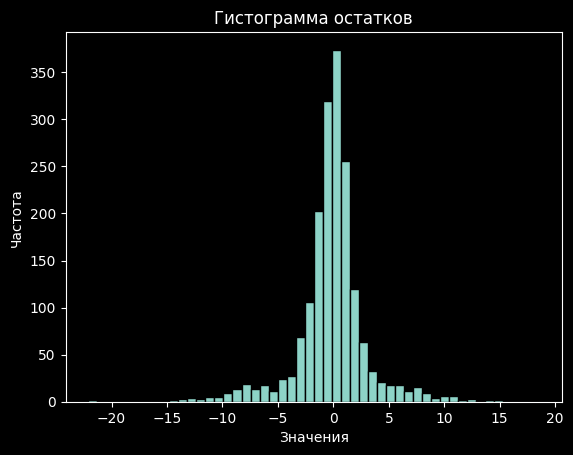

- p-value(тест Бера–Жарка)             - не выполнено (0.0)
Диагностика модели с 'p' = 1 и 'q' = 1 не пройдена (выполнено условий: 4)

Построенные модели не удовлетворяют всем условиям:
- лучшая модель с 'p' = 4 и 'q' = 3 (выполнено условий: 4)


In [43]:
def diagnostics(model, p, q):
    print(f"Диагностика модели с 'p' = {p} и 'q' = {q}:")

    result = True
    score  = 0



    # p-value
    if max(model.pvalues[:-1]) >= 0.05:
        print(f"{"- max(p-value(коэффициенты))":<38} - не выполнено ({max(model.pvalues[:-1])})")
        result = False
    else:
        print(f"{"- max(p-value(коэффициенты))":<38} -    выполнено ({max(model.pvalues[:-1])})")
        score += 1



    # Структура единичных корней
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

    ar_reverse = 1 / model.arroots
    ax1.scatter(np.real(ar_reverse), np.imag(ar_reverse))
    ax1.add_artist(plt.Circle((0, 0), 1, fill=False))
    ax1.set_title('Обратные корни AR')
    ax1.set_xlim(-1.1, 1.1)
    ax1.set_ylim(-1.1, 1.1)
    ax1.axhline(y=0, color='k', linestyle='--', alpha=0.5)
    ax1.axvline(x=0, color='k', linestyle='--', alpha=0.5)

    ma_reverse = 1 / model.maroots
    ax2.scatter(np.real(ma_reverse), np.imag(ma_reverse))
    ax2.add_artist(plt.Circle((0, 0), 1, fill=False))
    ax2.set_title('Обратные корни MA')
    ax2.set_xlim(-1.1, 1.1)
    ax2.set_ylim(-1.1, 1.1)
    ax2.axhline(y=0, color='k', linestyle='--', alpha=0.5)
    ax2.axvline(x=0, color='k', linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

    if max(abs(ar_reverse)) > 1 or max(abs(ma_reverse)) > 1:
        print(f"{"- Структура единичных корней":<38} - не выполнено")
        result = False
    else:
        print(f"{"- Структура единичных корней":<38} -    выполнено")
        score += 1



    # Коррелограммы
    acf_pacf(model.resid, 12)

    if min(acorr_ljungbox(model.resid, lags=min(30, len(current_values) // 5))['lb_pvalue']) < 0.05:
        print(f"{"- Коррелограммы":<38} - не выполнено")
        result = False
    else:
        print(f"{"- Коррелограммы":<38} -    выполнено")
        score += 1



    # Durbin-Watson statistic
    if not(1.6 < durbin_watson(model.resid) < 2.4):
        print(f"{"- Durbin-Watson statistic":<38} - не выполнено ({durbin_watson(model.resid)})")
        result = False
    else:
        print(f"{"- Durbin-Watson statistic":<38} -    выполнено ({durbin_watson(model.resid)})")
        score += 1



    # R-squared
    R_squared = 1 - np.sum(np.pow(current_values - model.fittedvalues, 2))/np.sum(np.pow(current_values - np.mean(current_values), 2))

    if R_squared < 0.5:
        print(f"{"- R-squared (коэффициент детерминации)":<38} - не выполнено ({R_squared})")
        result = False
    else:
        print(f"{"- R-squared (коэффициент детерминации)":<38} -    выполнено ({R_squared})")
        score += 1



    # F-statistic
    k = p + q

    F_statistic = (R_squared / k) / ((1 - R_squared) / (len(values) - k - 1))
    f_pvalue    = 1 - stats.f.cdf(F_statistic, k, len(values) - k - 1)

    if f_pvalue >= 0.05:
        print(f"{"- p-value(F-statistic)":<38} - не выполнено ({f_pvalue})")
        result = False
    else:
        print(f"{"- p-value(F-statistic)":<38} -    выполнено ({f_pvalue})")
        score += 1



    # Тест Бера–Жарка
    plt.hist(model.resid, bins=min(50, len(values) // 10), edgecolor='k')
    plt.title('Гистограмма остатков')
    plt.xlabel('Значения')
    plt.ylabel('Частота')
    plt.show()

    _, probability = jarque_bera(model.resid)

    if probability <= 0.05:
        print(f"{"- p-value(тест Бера–Жарка)":<38} - не выполнено ({probability})")
        result = False
    else:
        print(f"{"- p-value(тест Бера–Жарка)":<38} -    выполнено ({probability})")
        score += 1



    if result:
        print(f"Диагностика модели с 'p' = {p} и 'q' = {q} пройдена\n")
    else:
        print(f"Диагностика модели с 'p' = {p} и 'q' = {q} не пройдена (выполнено условий: {score})\n")

    return result, score



break_all = False
max_score = 0
order     = [1, 0, 3]

for i in range(p, 0, -1):
    for j in range(q, 0, -1):
        arima = ARIMA(current_values, exog=exog, order=(i, 0, j), trend='n').fit()
        result, score = diagnostics(arima, i, j)

        if max_score < score:
            max_score = score
            order     = [i, 0, j]

        if result:
            break_all = True
            break

    if break_all:
        break



if not break_all:
    print("Построенные модели не удовлетворяют всем условиям:")
    print(f"- лучшая модель с 'p' = {order[0]} и 'q' = {order[2]} (выполнено условий: {max_score})")

    arima = ARIMA(current_values, exog=exog, order=order, trend='n').fit()

# Лабораторная работа 5 - Модели условной гетероскедастичности

## Задание 1 - Идентификация порядков модели ARCH

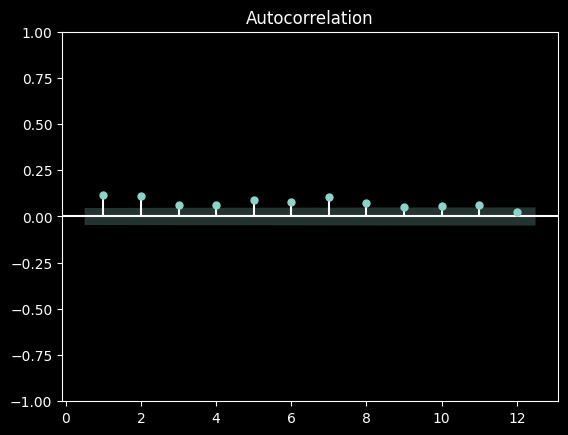

In [45]:
plot_acf(np.pow(arima.resid, 2), lags=12, zero=False)
plt.show()

p = int(input("Введите последний значимый лаг 'АКФ' перед первым незначимым: "))

- Порядок ARCH - это последний значимый лаг 'АКФ' перед первым незначимым (11)

## Задание 2 - Анализ остатков модели ARIMA на наличие ARCH-эффектов

In [46]:
for i in range(p, 0, -1):
    _, _, _, f_pvalue = het_arch(arima.resid, i)

    if f_pvalue < 0.05:
        print(f"- Модель ARCH({i}) имеет ARCH-эффекты (p-value(F-statistic) = {f_pvalue})")
        p = i
        break
    else:
        print(f"- Модель ARCH({i}) не имеет ARCH-эффектов (p-value(F-statistic) = {f_pvalue})")

        if i == 1:
            raise NameError("Остатки модели ARIMA не имеют ARCH-эффектов")

- Модель ARCH(11) имеет ARCH-эффекты (p-value(F-statistic) = 4.637999853682417e-12)


## Задание 3 - Построение моделей и получение оценок

In [47]:
def arch_garch(values, vol, p, q=0, dist='normal', cov_type='classic', output=False):
    model = arch_model(values, vol=vol, p=p, q=q, dist=dist).fit(update_freq=0, cov_type=cov_type)

    if output:
        print("- R-squared          (коэффициент детерминации):                                            ", model.rsquared)
        print("- R-squared-adjusted (скорректированный на число степеней свободы коэффициент детерминации):", model.rsquared_adj)

    return model



ARCH = arch_garch(arima.resid, vol='ARCH', p=p, output=True)

Optimization terminated successfully    (Exit mode 0)
            Current function value: 4604.52692998944
            Iterations: 25
            Function evaluations: 376
            Gradient evaluations: 25
- R-squared          (коэффициент детерминации):                                             0.0
- R-squared-adjusted (скорректированный на число степеней свободы коэффициент детерминации): 0.0


## Задание 4 - Подбор вида распределения

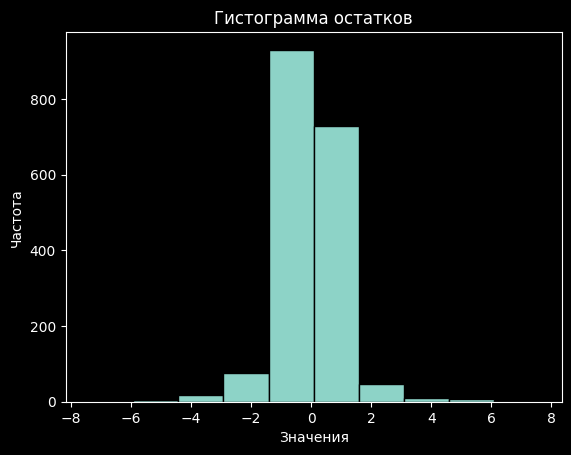

- p-value(тест Бера–Жарка) - не выполнен (0.0)
Перестроим модель ARCH с T-распределением
Optimization terminated successfully    (Exit mode 0)
            Current function value: 4208.248612096774
            Iterations: 27
            Function evaluations: 431
            Gradient evaluations: 27
- Модель ARCH статистически не значимая


In [49]:
def jarque_bera_test(residuals):
    plt.hist(residuals, edgecolor='k')
    plt.title('Гистограмма остатков')
    plt.xlabel('Значения')
    plt.ylabel('Частота')
    plt.show()

    _, probability = jarque_bera(residuals)

    if probability <= 0.05:
        print(f"{"- p-value(тест Бера–Жарка)"} - не выполнен ({probability})")
        return False
    else:
        print(f"{"- p-value(тест Бера–Жарка)"} -    выполнен ({probability})")
        return True



def selecting_the_type_of_distribution(model, residuals, vol, p, q=0):
    if jarque_bera_test(model.resid / model.conditional_volatility):
        return model
    else:
        print(f"Перестроим модель {vol} с T-распределением")

        return arch_garch(residuals, vol=vol, p=p, q=q, dist='t', cov_type='robust')



def statistical_significance(model, vol):
    if sum(model.params[2:-1]) < 1 and max(model.pvalues[2:-1]) < 0.05:
        print(f"- Модель {vol} статистически значимая")
    else:
        print(f"- Модель {vol} статистически не значимая")



ARCH = selecting_the_type_of_distribution(ARCH, arima.resid, vol='ARCH', p=p)

statistical_significance(ARCH, vol='ARCH')

## Задание 5 - Анализ качества построенных моделей

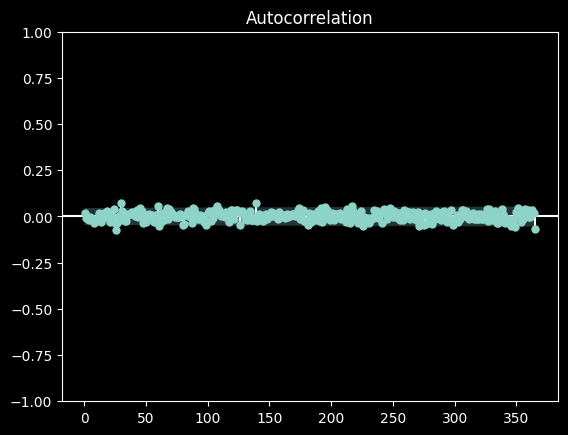

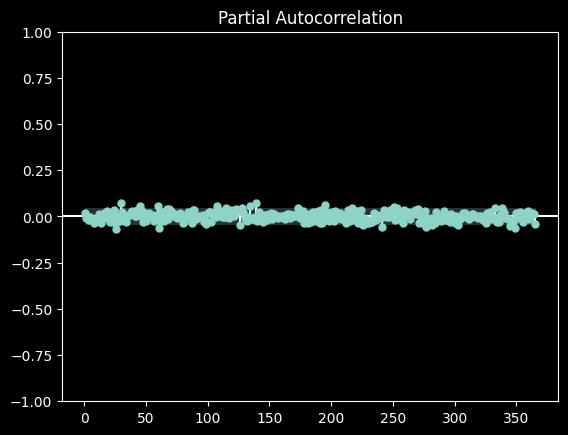

- Модель ARCH не имеет ARCH-эффектов (p-value(F-statistic) = 0.7148489138072367)


In [50]:
def quality_analysis(residuals, vol, p):
    # Коррелограммы
    acf_pacf(residuals, lags=T)

    # ARCH LM тест
    _, _, _, f_pvalue = het_arch(residuals, p)

    if f_pvalue > 0.05:
        print(f"- Модель {vol} не имеет ARCH-эффектов (p-value(F-statistic) = {f_pvalue})")
    else:
        print(f"- Модель {vol} имеет ARCH-эффекты (p-value(F-statistic) = {f_pvalue})")



quality_analysis(ARCH.resid / ARCH.conditional_volatility, vol='ARCH', p=p)

## Задание 6 - Построение и анализ GARCH модели

Optimization terminated successfully    (Exit mode 0)
            Current function value: 4562.497143147286
            Iterations: 17
            Function evaluations: 100
            Gradient evaluations: 17
- R-squared          (коэффициент детерминации):                                             0.0
- R-squared-adjusted (скорректированный на число степеней свободы коэффициент детерминации): 0.0


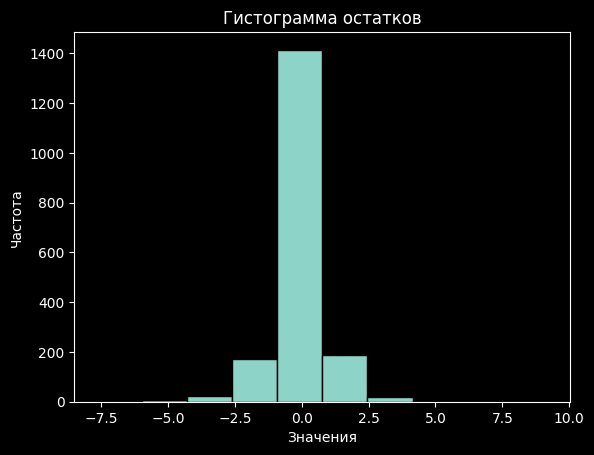

- p-value(тест Бера–Жарка) - не выполнен (0.0)
Перестроим модель GARCH с T-распределением
Optimization terminated successfully    (Exit mode 0)
            Current function value: 4182.5446821389805
            Iterations: 20
            Function evaluations: 136
            Gradient evaluations: 20
- Модель GARCH статистически не значимая


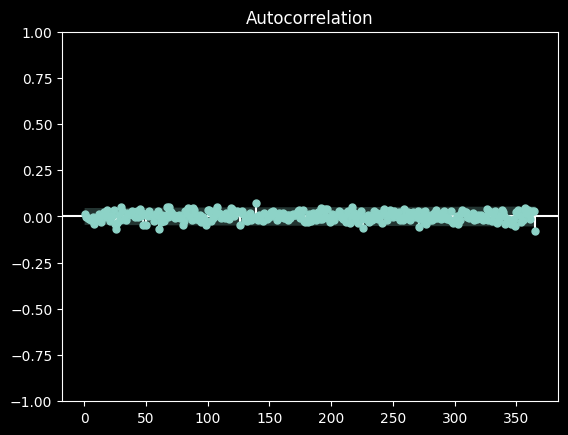

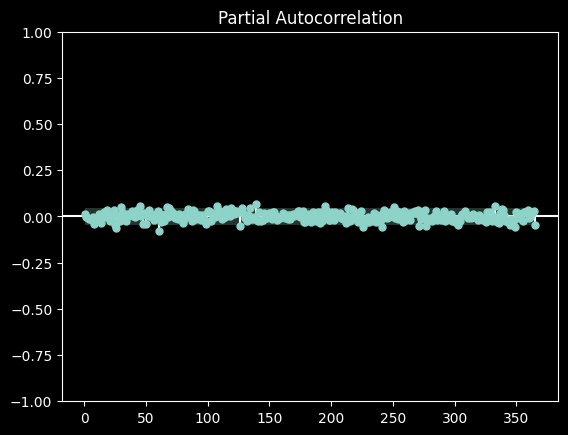

- Модель GARCH не имеет ARCH-эффектов (p-value(F-statistic) = 0.7036475374234424)


In [51]:
GARCH = arch_garch(arima.resid, vol='GARCH', p=1, q=1, output=True)

GARCH = selecting_the_type_of_distribution(GARCH, arima.resid, vol='GARCH', p=1, q=1)

statistical_significance(GARCH, vol='GARCH')

quality_analysis(GARCH.resid / GARCH.conditional_volatility, vol='GARCH', p=1)

## Задание 7 - Селекция ARCH и GARCH моделей

In [52]:
def selection(ARCH, GARCH):
    print(f"- ARCH:  AIC = {ARCH.aic} / - BIC = {ARCH.bic}")
    print(f"- GARCH: BIC = {GARCH.aic} / - BIC = {GARCH.bic}")

    if ARCH.aic < GARCH.aic:
        print("Выбрана модель ARCH")
        return "ARCH"
    else:
        print("Выбрана модель GARCH")
        return "GARCH"

ARCH_GARCH = selection(ARCH, GARCH)

- ARCH:  AIC = 8444.497224193548 / - BIC = 8521.62791791778
- GARCH: BIC = 8375.089364277961 / - BIC = 8402.636040608044
Выбрана модель GARCH


# Лабораторная работа 6 - Построение прогноза

## Задание 1 - Прогноз на основе модели ARIMA

In [53]:
def if_exog(exog, length):
    if exog:
        return exog[:length]
    else:
        return None



def trend(forecast):
    if trend_residuals:
        forecast += trend_residuals

    return forecast



steps = len(values) // 10

train = current_values[:-steps]
test  = values[-steps:]

### Динамический прогноз

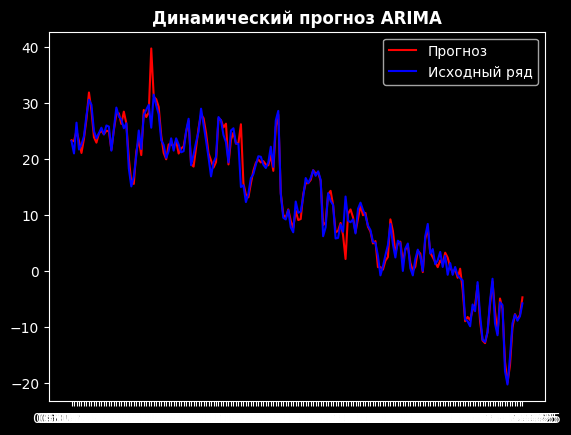

In [54]:
exog = if_exog(exog, len(train))

model = ARIMA(train, exog=exog, order=order, trend='n').fit()

arima_forecast = model.forecast(steps=steps)
arima_dynamic  = arima_forecast + test - residuals[best_seasonality][-steps:]
arima_dynamic  = trend(arima_dynamic)

plt.title("Динамический прогноз ARIMA", fontweight='bold')
plt.plot(time[-steps:], arima_dynamic,  "r", label="Прогноз")
plt.plot(time[-steps:], test,           "b", label="Исходный ряд")
plt.legend()
plt.show()

### Статистический прогноз

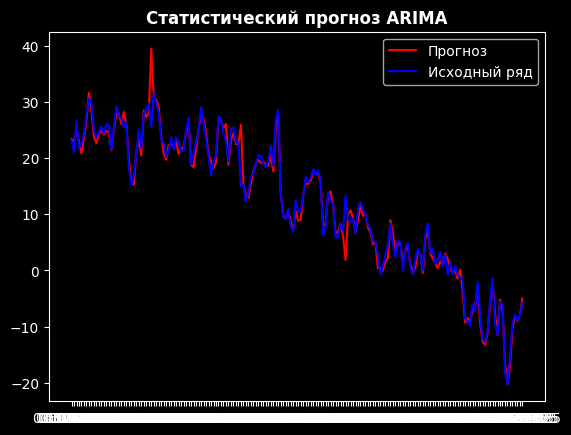

In [55]:
arima_statistical = []

for step in range(steps, 0, -1):
    exog = if_exog(exog, len(train))

    model = ARIMA(train, exog=exog, order=order, trend='n').fit()

    arima_forecast = model.forecast(steps=1)
    arima_statistical.append(arima_forecast + values[-step] - residuals[best_seasonality].iloc[-step])
    arima_statistical[-1] = trend(arima_statistical[-1])

    np.append(train, current_values.iloc[-step])



plt.title(f"Статистический прогноз ARIMA", fontweight='bold')
plt.plot(time[-steps:], arima_statistical, "r", label="Прогноз")
plt.plot(time[-steps:], test,              "b", label="Исходный ряд")
plt.legend()
plt.show()

## Задание 2 - Прогноз на основе модели ARCH/GARCH

In [56]:
def arch_garch_forecast(values, vol):
    if vol == 'ARCH':
        return arch_model(values, mean='AR', lags=order[0], vol='ARCH', p=p).fit(update_freq=0)
    else:
        return arch_model(values, mean='AR', lags=order[0], vol='GARCH', p=1, q=1).fit(update_freq=0)



train = arima.resid[:-steps]
test  = values[-steps:]

## Динамический прогноз

Optimization terminated successfully    (Exit mode 0)
            Current function value: 4157.483355449083
            Iterations: 21
            Function evaluations: 217
            Gradient evaluations: 21


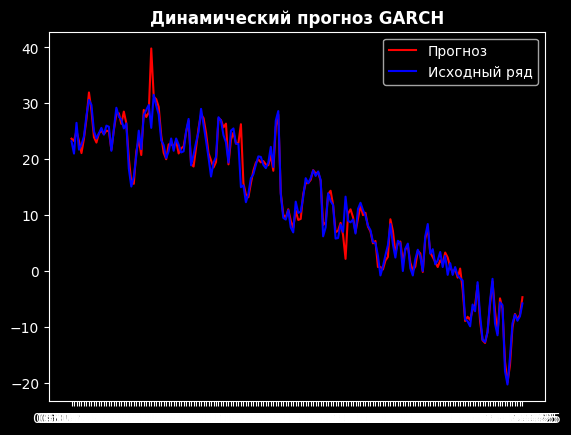

In [57]:
ARCH_GARCH_forecast = arch_garch_forecast(train, ARCH_GARCH).forecast(horizon=steps).mean.iloc[-1].tolist()
ARCH_GARCH_dynamic  = np.array(ARCH_GARCH_forecast) + test - residuals[best_seasonality][-steps:]
ARCH_GARCH_dynamic  = trend(ARCH_GARCH_dynamic)

plt.title(f"Динамический прогноз {ARCH_GARCH}", fontweight='bold')
plt.plot(time[-steps:], ARCH_GARCH_dynamic, "r", label="Прогноз")
plt.plot(time[-steps:], test,               "b", label="Исходный ряд")
plt.legend()
plt.show()

## Статистический прогноз

Optimization terminated successfully    (Exit mode 0)
            Current function value: 4157.483355449083
            Iterations: 21
            Function evaluations: 217
            Gradient evaluations: 21
Optimization terminated successfully    (Exit mode 0)
            Current function value: 4157.483355449083
            Iterations: 21
            Function evaluations: 217
            Gradient evaluations: 21
Optimization terminated successfully    (Exit mode 0)
            Current function value: 4157.483355449083
            Iterations: 21
            Function evaluations: 217
            Gradient evaluations: 21
Optimization terminated successfully    (Exit mode 0)
            Current function value: 4157.483355449083
            Iterations: 21
            Function evaluations: 217
            Gradient evaluations: 21
Optimization terminated successfully    (Exit mode 0)
            Current function value: 4157.483355449083
            Iterations: 21
            Function eval

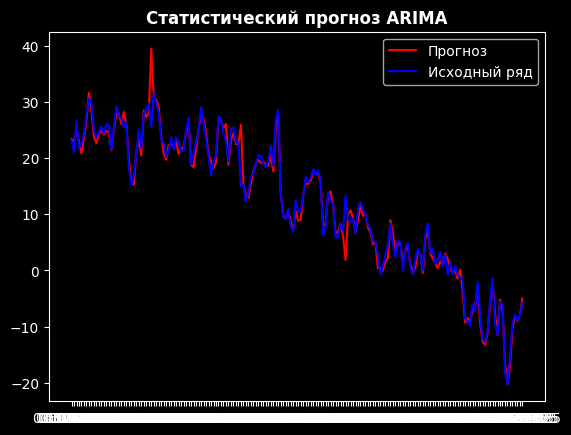

In [58]:
ARCH_GARCH_statistical = []

for step in range(steps, 0, -1):
    ARCH_GARCH_forecast = arch_garch_forecast(train, ARCH_GARCH).forecast(horizon=1).mean.iloc[-1].tolist()
    ARCH_GARCH_statistical.append(np.array(ARCH_GARCH_forecast) + values[-step] - residuals[best_seasonality].iloc[-steps])
    ARCH_GARCH_statistical[-1] = trend(ARCH_GARCH_statistical[-1])

    np.append(train, current_values.iloc[-step])



plt.title(f"Статистический прогноз ARIMA", fontweight='bold')
plt.plot(time[-steps:], arima_statistical, "r", label="Прогноз")
plt.plot(time[-steps:], test,              "b", label="Исходный ряд")
plt.legend()
plt.show()

## Задание 3 - Сравнение моделей

In [59]:
RMSE_arima_dynamic = np.sqrt(mean_squared_error(test, arima_dynamic))
MAE_arima_dynamic  = mean_absolute_error(test, arima_dynamic)
MAPE_arima_dynamic = mean_absolute_percentage_error(test, arima_dynamic)

RMSE_arima_statistical = np.sqrt(mean_squared_error(test, arima_statistical))
MAE_arima_statistical  = mean_absolute_error(test, arima_statistical)
MAPE_arima_statistical = mean_absolute_percentage_error(test, arima_statistical)

RMSE_ARCH_GARCH_dynamic = np.sqrt(mean_squared_error(test, ARCH_GARCH_dynamic))
MAE_ARCH_GARCH_dynamic  = mean_absolute_error(test, ARCH_GARCH_dynamic)
MAPE_ARCH_GARCH_dynamic = mean_absolute_percentage_error(test, ARCH_GARCH_dynamic)

RMSE_ARCH_GARCH_statistical = np.sqrt(mean_squared_error(test, ARCH_GARCH_statistical))
MAE_ARCH_GARCH_statistical  = mean_absolute_error(test, ARCH_GARCH_statistical)
MAPE_ARCH_GARCH_statistical = mean_absolute_percentage_error(test, ARCH_GARCH_statistical)



print(f"{"Сравнение":<30} | {"RMSE":<20} | {"MAE":<20} | {"MAPE":<20}")
print('-' * 100)
print(f"{"- динамическая модель ARIMA":<30} | {RMSE_arima_dynamic:>20} | {MAE_arima_dynamic:>20} | {MAPE_arima_dynamic:>20}")
print(f"{"- статистическая ARIMA":<30} | {RMSE_arima_statistical:>20} | {MAE_arima_statistical:>20} | {MAPE_arima_statistical:>20}")
print(f"{f"- динамическая модель {ARCH_GARCH}":<30} | {RMSE_ARCH_GARCH_dynamic:>20} | {MAE_ARCH_GARCH_dynamic:>20} | {MAPE_ARCH_GARCH_dynamic:>20}")
print(f"{f"- статистическая модель {ARCH_GARCH}":<30} | {RMSE_ARCH_GARCH_statistical:>20} | {MAE_ARCH_GARCH_statistical:>20} | {MAPE_ARCH_GARCH_statistical:>20}")



RMSE = [RMSE_arima_dynamic, RMSE_arima_statistical, RMSE_ARCH_GARCH_dynamic, RMSE_ARCH_GARCH_statistical]
MAE  = [MAE_arima_dynamic, MAE_arima_statistical, MAE_ARCH_GARCH_dynamic, MAE_ARCH_GARCH_statistical]
MAPE = [MAPE_arima_dynamic, MAE_arima_statistical, MAPE_ARCH_GARCH_dynamic, MAPE_ARCH_GARCH_statistical]

best = [RMSE.index(min(RMSE)), MAE.index(min(MAE)), MAPE.index(min(MAPE))]
best = [best.count(0), best.count(1), best.count(2), best.count(3)]
best = best.index(max(best))

if best == 0:
    print("\nЛучшая - динамическая модель ARIMA")
elif best == 1:
    print("\nЛучшая - статистическая модель ARIMA")
elif best == 2:
    print(f"\nЛучшая - динамическая модель {ARCH_GARCH}")
else:
    print(f"\nЛучшая - статистическая модель {ARCH_GARCH}")

Сравнение                      | RMSE                 | MAE                  | MAPE                
----------------------------------------------------------------------------------------------------
- динамическая модель ARIMA    |   1.8994939707320535 |   1.0447595463790642 |    44399821618384.95
- статистическая ARIMA         |   1.9069731647242694 |   1.0814892100816949 |    44399821618384.95
- динамическая модель GARCH    |   1.9023620362886504 |   1.0451633181965416 |    44399821618384.95
- статистическая модель GARCH  |    0.463493316471628 |   0.4634933164716279 |   22938333267586.258

Лучшая - статистическая модель GARCH


## Задание 4 - Вывод

In [60]:
print("- Лабораторные работы 1-6 выполнены")

- Лабораторные работы 1-6 выполнены
